# Final results

Every figure, table and number quoted in the report, in the order the report presents them. Each
figure is saved as a PNG in `paleoreco.paths.REPORT_FIGURES` under the file name given in its
heading. Nothing here runs an estimator: it reads the stored lane and product artefacts and the
raw inputs.

In [1]:
import os
import sys
from pathlib import Path

# A fixed single thread keeps floating-point results identical from run to run; it only takes
# effect if set before numpy loads.
for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
            "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(var, "1")
assert "numpy" not in sys.modules, "restart the kernel: numpy loaded before the thread cap"
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
%matplotlib inline
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from scipy import stats as sps

from paleoreco import paths
from paleoreco.assim import experiments as ex
from paleoreco.assim.background import temporal_structure_function
from paleoreco.assim.innovation import obs_cell_index
from paleoreco.assim.observations import (
    collapse_to_samples, observations_at_age, sample_block_centres,
)
from paleoreco.data import VARS
from paleoreco.data.splits import DO_EVENT_WINDOWS, DO_ONSET_BP, chronological_half_split
from paleoreco.eval import da
from paleoreco.report import diagrams, stats
from paleoreco.report.maps import CELL_DEG, PLATE, draw_field, map_axes
from paleoreco.report.results import (
    ablation_metrics, config, inherited_taper, lane_rows, load_inputs, metrics,
    operating_point, pooled, run_artifact, selected_by_amplitude, value,
)
from paleoreco.report.style import (
    DIFF_CMAP, ESTIMATORS, PRODUCT_C, REPORT_WIDTH, SIM_C, count_axis, save, use_report_style,
)

use_report_style()
pd.set_option("display.precision", 4)

inp = load_inputs()
cube, ages, lats, lons, valid = inp.cube, inp.ages, inp.lats, inp.lons, inp.valid
long, raw, recon = inp.long, inp.raw, inp.recon
N_CELLS = len(lats) * len(lons)
EST_3DVAR, EST_HG, EST_MT = ex.ESTIMATOR_3DVAR, ex.ESTIMATOR_HGAOENKF, ex.ESTIMATOR_HGAOENKF_MT
LANES = (paths.LANE_PPE, paths.LANE_TRAJECTORY, paths.LANE_WITHHOLDING)
LANE_NAME = {paths.LANE_PPE: "snapshot", paths.LANE_TRAJECTORY: "time series",
             paths.LANE_WITHHOLDING: "withholding"}

## Chapter 1: Introduction

### Figure 1.1: the reconstruction problem (`fig01_01_reconstruction_problem`)

age 38175 yr BP: 95 MTCO sites reaching 71 of 2048 cells (3.5%)


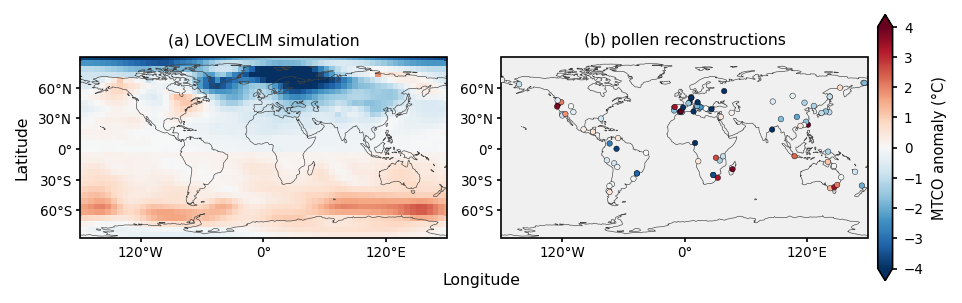

In [3]:
AGE_FIG11 = 38175          # onset of D-O event 8 on the archive's age axis
CHAN_FIG11 = 0             # MTCO

ti = int(np.argmin(np.abs(recon["ages"] - AGE_FIG11)))
age = int(recon["ages"][ti])
safe_valid, clim = recon["safe_valid"], recon["clim_mean"]
sim_anom = cube[np.searchsorted(ages, age)].astype(np.float64) - clim

o = observations_at_age(long, age)
sel = (o["channel"] == VARS[CHAN_FIG11]) & np.isfinite(o["my"])
obs_lat, obs_lon = o["lat"][sel], o["lon"][sel]
obs_anom = (o["y"][sel] - o["my"][sel]).astype(np.float64)
cells_hit = np.unique(obs_cell_index(o["lat"], o["lon"], o["channel"], lats, lons)[sel] % N_CELLS)

V = 4.0
fig, axes = plt.subplots(1, 2, figsize=(REPORT_WIDTH, 1.95), subplot_kw={"projection": PLATE},
                         constrained_layout=True)
mesh = draw_field(axes[0], lats, lons, np.where(safe_valid, sim_anom[CHAN_FIG11], np.nan),
                  vmin=-V, vmax=V)
axes[0].set_title("(a) LOVECLIM simulation")
axes[1].set_facecolor("0.94")
axes[1].scatter(obs_lon, obs_lat, c=obs_anom, s=7, cmap="RdBu_r", vmin=-V, vmax=V,
                edgecolor="k", linewidth=0.2, transform=PLATE, zorder=3)
axes[1].set_title("(b) pollen reconstructions")
for i, ax in enumerate(axes):
    map_axes(ax, ylabel=(i == 0))
fig.supxlabel("Longitude", fontsize=7.5, y=0.02)
cb = fig.colorbar(mesh, ax=axes, shrink=0.95, pad=0.012, aspect=18, extend="both")
cb.set_label(f"{VARS[CHAN_FIG11].upper()} anomaly (°C)", fontsize=7)
cb.ax.tick_params(labelsize=6.5, length=2)
save(fig, "fig01_01_reconstruction_problem")

print(f"age {age} yr BP: {sel.sum()} MTCO sites reaching {len(cells_hit)} of {N_CELLS} cells "
      f"({100 * len(cells_hit) / N_CELLS:.1f}%)")

## Chapter 2: Background and related work

### Figure 2.1: method families (`fig02_01_method_family_map`)

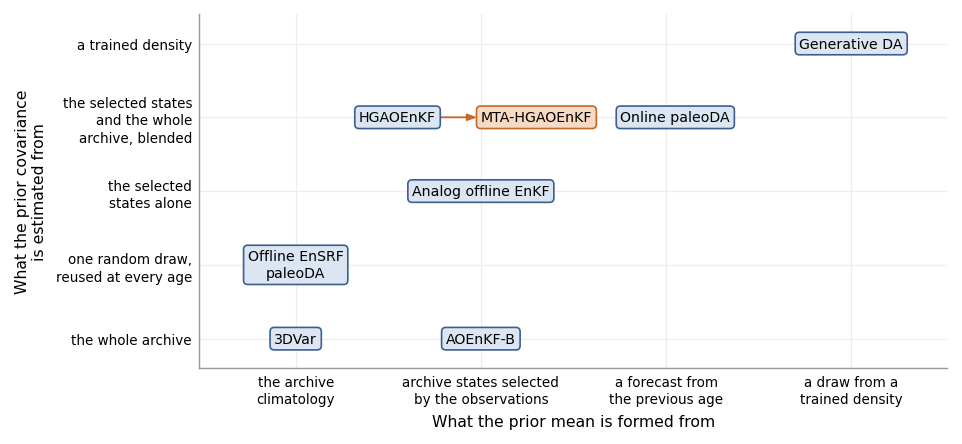

In [4]:
fig = diagrams.method_family_map()
save(fig, "fig02_01_method_family_map")

## Chapter 3: Understanding the data

### Figure 3.1: per-cell structure of the archive (`fig03_01_prior_structure`)

mtco: per-cell s.d. median 0.58 degC, 90th pct 2.49
mtwa: per-cell s.d. median 0.73 degC, 90th pct 2.83
median lag-1 autocorrelation over all cell-channel series: 0.948


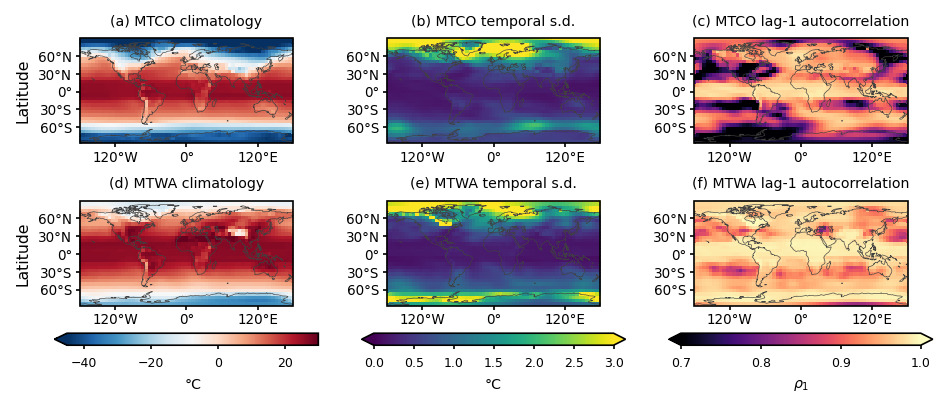

In [5]:
mean_all, std_all = cube.mean(axis=0), cube.std(axis=0)
r1 = np.stack([stats.lag1_autocorr(cube[:, 0].astype(np.float64)),
               stats.lag1_autocorr(cube[:, 1].astype(np.float64))])
r1_med = float(np.median(r1[:, valid]))

COLS = [("climatology", mean_all, dict(vmin=-45, vmax=30, cmap="RdBu_r"), "°C"),
        ("temporal s.d.", std_all, dict(vmin=0, vmax=3.0, cmap="viridis"), "°C"),
        ("lag-1 autocorrelation", r1, dict(vmin=0.7, vmax=1.0, cmap="magma"), r"$\rho_1$")]
fig, axes = plt.subplots(2, 3, figsize=(REPORT_WIDTH, 2.60), subplot_kw={"projection": PLATE},
                         constrained_layout=True)
for j, (label, field, kw, unit) in enumerate(COLS):
    for c, name in enumerate(VARS):
        mesh = draw_field(axes[c, j], lats, lons, np.where(valid, field[c], np.nan), **kw)
        axes[c, j].set_title(f"({'adbecf'[2 * j + c]}) {name.upper()} {label}", fontsize=6.8)
        map_axes(axes[c, j], ylabel=(j == 0))
    cb = fig.colorbar(mesh, ax=axes[:, j], orientation="horizontal", shrink=0.92, pad=0.02,
                      aspect=22, extend="both" if j else "min")
    cb.set_label(unit, fontsize=6.8)
    cb.ax.tick_params(labelsize=6, length=2)
save(fig, "fig03_01_prior_structure")

for c, name in enumerate(VARS):
    print(f"{name}: per-cell s.d. median {np.median(std_all[c][valid]):.2f} degC, "
          f"90th pct {np.percentile(std_all[c][valid], 90):.2f}")
print(f"median lag-1 autocorrelation over all cell-channel series: {r1_med:.3f}")

### Figure 3.2: the proxy network in space and time (`fig03_02_proxy_network`)

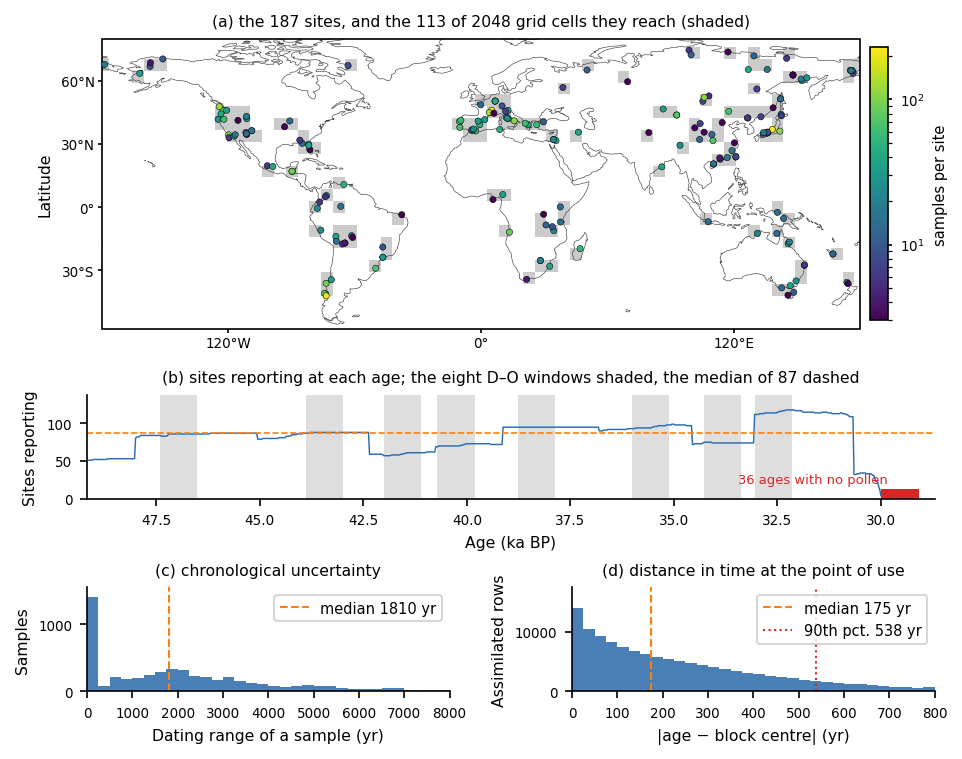

In [6]:
reached = stats.cells_reached(long, lats, lons)
sites = raw.groupby("siteID").agg(lat=("latitude", "first"), lon=("longitude", "first"),
                                  n=("sampleID", "nunique"))
per_age = raw.groupby("age")["siteID"].nunique()
free_ages = np.setdiff1d(ages, per_age.index.to_numpy())
date_range = (raw.drop_duplicates("sampleID").eval("age_oldest - age_youngest")).to_numpy()
lag_yr = sample_block_centres(long).eval("age - centre").abs().to_numpy()

fig = plt.figure(figsize=(REPORT_WIDTH, 4.95), layout="constrained")
sub_top, sub_bot = fig.subfigures(2, 1, height_ratios=[2.35, 2.60])

ax = sub_top.subplots(subplot_kw={"projection": PLATE})
# Freeze the extent before drawing, or the wrapped mesh re-autoscales the axes and the layout
# sizes the box to that wider aspect.
ax.set_extent([-180, 180, -58, 80], crs=PLATE)
ax.set_autoscale_on(False)
draw_field(ax, lats, lons, np.where(reached, 1.0, np.nan), vmin=0, vmax=3.2, cmap="Greys")
ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.3, edgecolor="0.25")
sc = ax.scatter(sites["lon"], sites["lat"], c=sites["n"], s=9, cmap="viridis",
                norm=plt.matplotlib.colors.LogNorm(), edgecolor="k", linewidth=0.25,
                transform=PLATE, zorder=3)
ax.set_xticks([-120, 0, 120], crs=PLATE)
ax.set_yticks([-30, 0, 30, 60], crs=PLATE)
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel("Latitude")
ax.tick_params(length=2, pad=1.5)
ax.set_title(f"(a) the {len(sites)} sites, and the {int(reached.sum())} of {N_CELLS} "
             "grid cells they reach (shaded)")
cb = sub_top.colorbar(sc, ax=ax, shrink=0.94, pad=0.012, aspect=15)
cb.set_label("samples per site", fontsize=7)
cb.ax.tick_params(labelsize=6.5, length=2)

gs = sub_bot.add_gridspec(2, 2, height_ratios=[1.0, 1.0])
axb = sub_bot.add_subplot(gs[0, :])
for lo_, hi in DO_EVENT_WINDOWS.values():
    axb.axvspan(lo_ / 1000, hi / 1000, color="0.87", lw=0, zorder=0)
axb.plot(per_age.index.to_numpy() / 1000, per_age.to_numpy(), lw=0.7, color="#2b6cb0")
axb.axhline(per_age.median(), color="C1", lw=0.8, ls="--")
axb.plot(free_ages / 1000, np.full_like(free_ages, 6.0, dtype=float), lw=0, marker="|",
         ms=5, color="C3")
axb.annotate(f"{len(free_ages)} ages with no pollen", (free_ages.mean() / 1000, 6.0),
             textcoords="offset points", xytext=(-6, 4), ha="right", va="bottom",
             fontsize=6.3, color="C3")
axb.set_xlim(ages.max() / 1000, ages.min() / 1000 - 0.4)
axb.set_ylim(0, 138)
axb.set_xlabel("Age (ka BP)")
axb.set_ylabel("Sites reporting")
axb.set_title("(b) sites reporting at each age; the eight D–O windows shaded, "
              f"the median of {int(per_age.median())} dashed")

axc = sub_bot.add_subplot(gs[1, 0])
axc.hist(date_range, bins=np.arange(0, 8001, 250), color="#4a7fb5")
axc.axvline(np.median(date_range), color="C1", lw=1.0, ls="--",
            label=f"median {np.median(date_range):.0f} yr")
axc.set_xlim(0, 8000)
axc.set_ylim(0, 1550)
axc.set_xlabel("Dating range of a sample (yr)")
axc.set_ylabel("Samples")
axc.legend(loc="upper right")
axc.set_title("(c) chronological uncertainty")

axd = sub_bot.add_subplot(gs[1, 1])
axd.hist(lag_yr, bins=np.arange(0, 801, 25), color="#4a7fb5")
axd.axvline(np.median(lag_yr), color="C1", lw=1.0, ls="--",
            label=f"median {np.median(lag_yr):.0f} yr")
axd.axvline(np.percentile(lag_yr, 90), color="C3", lw=1.0, ls=":",
            label=f"90th pct. {np.percentile(lag_yr, 90):.0f} yr")
axd.set_xlim(0, 800)
axd.set_ylim(0, 17500)
axd.set_xlabel("|age − block centre| (yr)")
axd.set_ylabel("Assimilated rows")
axd.legend(loc="upper right")
axd.set_title("(d) distance in time at the point of use")
save(fig, "fig03_02_proxy_network")

In [7]:
samples = collapse_to_samples(long)            # one row per (site, channel, sample)
obs_per_age = long.groupby("age").size()
nh = int((sites["lat"] > 0).sum())
print(f"{long['site'].nunique()} sites, {long['sample'].nunique()} samples, "
      f"{len(samples):,} measurements, {len(long):,} assimilated rows")
print(f"sites per age: median {int(per_age.median())}, range {per_age.min()}-{per_age.max()}; "
      f"observations per age: median {int(obs_per_age.median())}")
print(f"ages with pollen: {per_age.size} of {len(ages)}; {len(free_ages)} without, "
      f"{free_ages.max()}-{free_ages.min()} yr BP")
print(f"cells reached: {int(reached.sum())} of {N_CELLS} ({100 * reached.sum() / N_CELLS:.1f}%)")
print(f"Northern Hemisphere sites: {nh} of {len(sites)} ({100 * nh / len(sites):.1f}%); "
      f"latitude {sites['lat'].min():.1f} to {sites['lat'].max():.1f}")
print(f"samples dated to a single age: {(date_range == 0).mean():.3f}")
print(f"dating range: median {np.median(date_range):.0f} yr, IQR "
      f"{np.percentile(date_range, 25):.0f}-{np.percentile(date_range, 75):.0f}, "
      f"max {date_range.max():.0f}")
print(f"lag at use: median {np.median(lag_yr):.0f} yr, 90th pct {np.percentile(lag_yr, 90):.0f}, "
      f"max {lag_yr.max():.0f}")

187 sites, 5384 samples, 10,768 measurements, 127,646 assimilated rows
sites per age: median 87, range 4-118; observations per age: median 174
ages with pollen: 768 of 804; 36 without, 29975-29100 yr BP
cells reached: 113 of 2048 (5.5%)
Northern Hemisphere sites: 139 of 187 (74.3%); latitude -42.2 to 74.5
samples dated to a single age: 0.261
dating range: median 1810 yr, IQR 0-3220, max 24160
lag at use: median 175 yr, 90th pct 538, max 1438


### Figure 3.3: model-proxy offset and archive renewal (`fig03_03_offset_and_scarcity`)

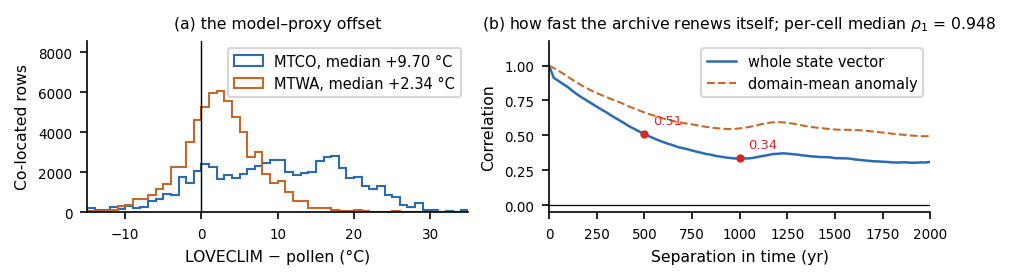

In [8]:
ai = stats.nearest_index(raw["age"].to_numpy(), ages)
la = stats.nearest_index(raw["latitude"].to_numpy(), lats)
lo_ = stats.nearest_index(raw["longitude"].to_numpy(), lons)
resid = {"mtco": cube[ai, 0, la, lo_] - raw["mtco"].to_numpy(),
         "mtwa": cube[ai, 1, la, lo_] - raw["mtwa"].to_numpy()}
acf, svc = stats.decorrelation(cube, valid)
lags = np.arange(0, 81)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(REPORT_WIDTH, 1.75), constrained_layout=True)
for ch, col in zip(VARS, ("#2b6cb0", "#c4692a")):
    axa.hist(resid[ch], bins=np.arange(-15, 35.1, 1.0), histtype="step", lw=1.0, color=col,
             label=f"{ch.upper()}, median {np.median(resid[ch]):+.2f} °C")
axa.axvline(0, color="k", lw=0.7)
axa.set_xlim(-15, 35)
axa.set_ylim(0, 8600)
axa.set_xlabel("LOVECLIM − pollen (°C)")
axa.set_ylabel("Co-located rows")
axa.legend(loc="upper right")
axa.set_title("(a) the model–proxy offset")

axb.plot(lags * 25, svc[:81], lw=1.2, color="#2b6cb0", label="whole state vector")
axb.plot(lags * 25, acf, lw=1.0, ls="--", color="#c4692a", label="domain-mean anomaly")
axb.axhline(0, color="k", lw=0.6)
for yr in (500, 1000):
    k = yr // 25
    axb.plot([yr], [svc[k]], marker="o", ms=3, color="C3")
    axb.annotate(f"{svc[k]:.2f}", (yr, svc[k]), textcoords="offset points", xytext=(4, 5),
                 fontsize=6.3, color="C3")
axb.set_xlim(0, 2000)
axb.set_ylim(-0.05, 1.18)
axb.set_xlabel("Separation in time (yr)")
axb.set_ylabel("Correlation")
axb.legend(loc="upper right")
axb.set_title(f"(b) how fast the archive renews itself; "
              f"per-cell median $\\rho_1$ = {r1_med:.3f}")
save(fig, "fig03_03_offset_and_scarcity")

In [9]:
offset = stats.site_frame_offset(cube, ages, samples, lats, lons)
span = samples.groupby(["site", "channel"])["age"].agg(lambda a: a.max() - a.min())
med_sse = samples["sse"].median()
for ch in VARS:
    print(f"LOVECLIM minus pollen, {ch}: median {np.median(resid[ch]):+.2f} degC")
print(f"site-channel records spanning under half the record: "
      f"{(span / (ages.max() - ages.min()) < 0.5).mean():.2f}")
print(f"site-frame error: median |.| {np.median(np.abs(offset)):.2f} degC, "
      f"rms {np.sqrt((offset ** 2).mean()):.2f} degC; squared, "
      f"{100 * np.median(np.abs(offset)) ** 2 / med_sse:.1f}% and "
      f"{100 * (offset ** 2).mean() / med_sse:.1f}% of the median error variance "
      f"({med_sse:.2f} degC^2)")
print(f"state-vector correlation at 500 yr {svc[20]:.2f}, at 1000 yr {svc[40]:.2f}")

LOVECLIM minus pollen, mtco: median +9.70 degC
LOVECLIM minus pollen, mtwa: median +2.34 degC
site-channel records spanning under half the record: 0.52
site-frame error: median |.| 0.13 degC, rms 0.35 degC; squared, 1.8% and 12.5% of the median error variance (1.00 degC^2)
state-vector correlation at 500 yr 0.51, at 1000 yr 0.34


### Figure 3.4: the archive's leading principal components (`fig03_04_prior_principal_components`)

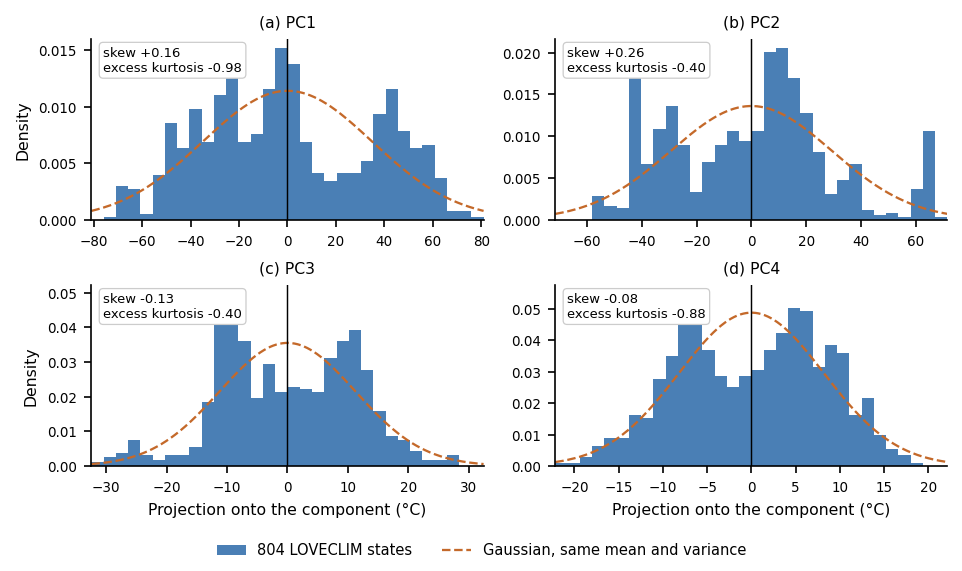

In [10]:
N_PC = 4
pc_scores, pc_share = stats.leading_pcs(cube, lats, N_PC)

fig, axes = plt.subplots(2, 2, figsize=(REPORT_WIDTH, 3.70), constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    z = pc_scores[:, i]
    lim = float(np.abs(z).max()) * 1.06
    # About 25 of the 804 states per bin: enough to resolve the gap between the lumps.
    ax.hist(z, bins=np.linspace(-lim, lim, 33), density=True, color="#4a7fb5",
            label=f"{len(ages)} LOVECLIM states" if i == 0 else None)
    grid = np.linspace(-lim, lim, 512)
    ax.plot(grid, sps.norm.pdf(grid, z.mean(), z.std()), lw=1.1, ls="--",
            color="#c4692a", label="Gaussian, same mean and variance" if i == 0 else None)
    ax.axvline(z.mean(), color="k", lw=0.7)
    ax.set_xlim(-lim, lim)
    ax.set_title(f"({'abcd'[i]}) PC{i + 1}")
    if i >= 2:
        ax.set_xlabel("Projection onto the component (°C)")
    if i % 2 == 0:
        ax.set_ylabel("Density")
    ax.text(0.03, 0.96,
            f"skew {sps.skew(z):+.2f}\nexcess kurtosis {sps.kurtosis(z):+.2f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=6.3,
            bbox=dict(boxstyle="round,pad=0.30", facecolor="white", edgecolor="0.8",
                      linewidth=0.6))
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="outside lower center", ncols=2,
           frameon=False)
save(fig, "fig03_04_prior_principal_components")

### Figure 3.5: the simulation as a time series (`fig03_05_simulation_timeseries`)

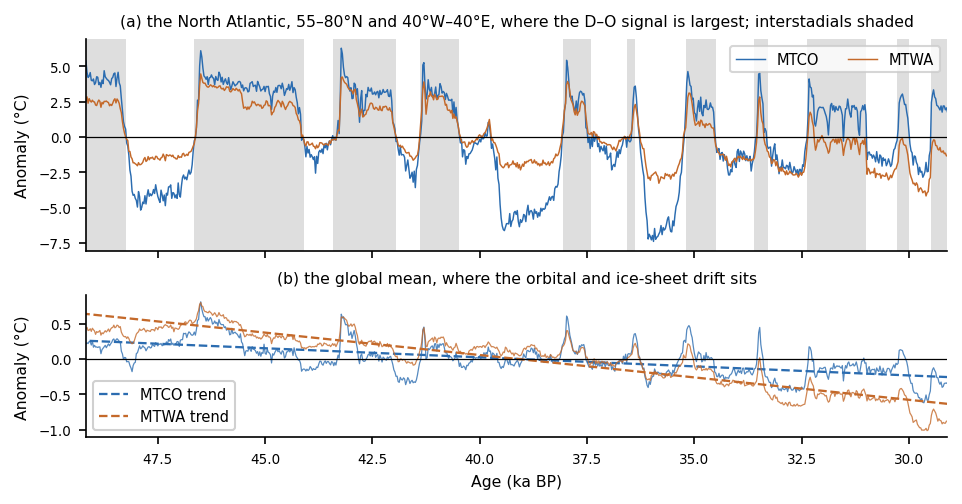

In [11]:
cyc_lat, cyc_lon = np.meshgrid(lats, lons, indexing="ij")
natl_box = ((cyc_lat >= 55) & (cyc_lat <= 80)
            & (np.abs(((cyc_lon + 180) % 360) - 180) <= 40))
area_w = stats.area_weights(lats, lons)


def anom_index(channel, weights):
    v = stats.area_mean(cube[:, channel].astype(np.float64), weights)
    return v - v.mean()


natl_idx = [anom_index(c, area_w * natl_box) for c in range(len(VARS))]
glob_idx = [anom_index(c, area_w) for c in range(len(VARS))]

# Interstadials are shaded where the 400 yr running mean of the winter index sits above its median.
step_yr = float(np.diff(ages)[0])
k_smooth = int(400.0 / step_yr) | 1
smoothed = np.convolve(np.pad(natl_idx[0], (k_smooth // 2, k_smooth // 2), mode="edge"),
                       np.ones(k_smooth) / k_smooth, "valid")[:len(ages)]
warm = smoothed > np.median(smoothed)
breaks = np.flatnonzero(np.diff(warm.astype(int)) != 0) + 1

ka = ages / 1000.0
fig, (axa, axb) = plt.subplots(2, 1, figsize=(REPORT_WIDTH, 3.25), sharex=True,
                               gridspec_kw={"height_ratios": [1.5, 1.0]},
                               constrained_layout=True)
for i0, i1 in zip(np.r_[0, breaks], np.r_[breaks, len(ages)]):
    if warm[i0]:
        axa.axvspan(ka[i0], ka[i1 - 1], color="0.87", lw=0, zorder=0)
for c, col in zip(range(len(VARS)), ("#2b6cb0", "#c4692a")):
    axa.plot(ka, natl_idx[c], lw=0.7, color=col, label=VARS[c].upper())
axa.axhline(0.0, color="k", lw=0.6)
axa.set_ylabel("Anomaly (°C)")
axa.legend(loc="upper right", ncols=2)
axa.set_title("(a) the North Atlantic, 55–80°N and 40°W–40°E, where the D–O signal is "
              "largest; interstadials shaded")

trend_basis = np.vander((ages - ages.mean()) / ages.std(), 2)
for c, col in zip(range(len(VARS)), ("#2b6cb0", "#c4692a")):
    v = glob_idx[c]
    fit = trend_basis @ np.linalg.lstsq(trend_basis, v, rcond=None)[0]
    axb.plot(ka, v, lw=0.6, color=col, alpha=0.8)
    axb.plot(ka, fit, lw=1.1, ls="--", color=col, label=f"{VARS[c].upper()} trend")
axb.axhline(0.0, color="k", lw=0.6)
axb.set_xlim(ka.max(), ka.min())
axb.set_xlabel("Age (ka BP)")
axb.set_ylabel("Anomaly (°C)")
axb.legend(loc="lower left", ncols=1, framealpha=0.92)
axb.set_title("(b) the global mean, where the orbital and ice-sheet drift sits")
save(fig, "fig03_05_simulation_timeseries")

### Table 3.1: the two datasets

In [12]:
D = len(VARS) * len(lats) * len(lons)
prior_half = chronological_half_split(ages, stride=1)[0]
rank_all = stats.covariance_rank(cube, np.arange(len(ages)))[0]
rank_half = stats.covariance_rank(cube, prior_half)[0]
efold = int(np.argmax(svc < np.exp(-1))) * 25
sse_med = samples.groupby("channel")["sse"].median()
pd.DataFrame([
    ("Grid", f"{len(lats)} x {len(lons)} at {CELL_DEG} deg, {N_CELLS} cells"),
    ("Channels", ", ".join(v.upper() for v in VARS)),
    ("State dimension", f"D = {D}"),
    ("Covariance free parameters", f"D(D+1)/2 = {D * (D + 1) // 2:,}"),
    ("States", f"{len(ages)}"),
    ("Age range, spacing", f"{ages.max()}-{ages.min()} yr BP, {int(np.diff(ages)[0])} yr"),
    ("Sample covariance rank", f"<= {len(ages) - 1} of {D} (numerical {rank_all}); "
                               f"<= {len(prior_half) - 1} on the {len(prior_half)}-state "
                               f"prior half (numerical {rank_half})"),
    ("State decorrelation time", f"{efold} yr at 1/e; correlation {svc[1]:.2f} at 25 yr"),
    ("Median per-cell temporal s.d.", f"{np.median(std_all[0][valid]):.2f} (MTCO), "
                                      f"{np.median(std_all[1][valid]):.2f} (MTWA) degC"),
    ("Sites, samples", f"{long['site'].nunique()}, {long['sample'].nunique()}"),
    ("Measurements, assimilated rows", f"{len(samples):,}; {len(long):,}"),
    ("Ages covered", f"{per_age.size} of {len(ages)} ({len(free_ages)} empty, "
                     f"{free_ages.min()}-{free_ages.max()} yr BP)"),
    ("Sites per age", f"median {int(per_age.median())}, range {per_age.min()}-{per_age.max()}"),
    ("Grid cells reached", f"{int(reached.sum())} of {N_CELLS} "
                           f"({100 * reached.sum() / N_CELLS:.1f}%)"),
    ("Northern Hemisphere sites", f"{nh} of {len(sites)} ({100 * nh / len(sites):.1f}%); "
                                  f"latitude {sites['lat'].min():.1f} to {sites['lat'].max():.1f}"),
    ("Median error variance", f"{sse_med['mtco']:.2f} (MTCO), {sse_med['mtwa']:.2f} (MTWA) degC^2"),
    ("Median dating range", f"{np.median(date_range):.0f} yr (IQR "
                            f"{np.percentile(date_range, 25):.0f}-"
                            f"{np.percentile(date_range, 75):.0f}, max {date_range.max():.0f})"),
    ("Median lag at use", f"{np.median(lag_yr):.0f} yr (90th pct "
                          f"{np.percentile(lag_yr, 90):.0f}, max {lag_yr.max():.0f})"),
], columns=["Property", "Value"]).set_index("Property")

,Value
Property,
Grid,"32 x 64 at 5.625 deg, 2048 cells"
Channels,"MTCO, MTWA"
State dimension,D = 4096
Covariance free parameters,"D(D+1)/2 = 8,390,656"
States,804
"Age range, spacing","49175-29100 yr BP, 25 yr"
Sample covariance rank,<= 803 of 4096 (numerical 803); <= 401 on the ...
State decorrelation time,825 yr at 1/e; correlation 0.91 at 25 yr
Median per-cell temporal s.d.,"0.58 (MTCO), 0.73 (MTWA) degC"


## Chapter 4: Experimental design

### Table 4.1: the three evaluation lanes

In [13]:
ppe_cfg = config(EST_3DVAR, paths.LANE_PPE)
traj_cfg = config(EST_3DVAR, paths.LANE_TRAJECTORY)
wh_cfg = config(EST_3DVAR, paths.LANE_WITHHOLDING)
pd.DataFrame({
    "prior states": [ppe_cfg["prior_meta"]["n_prior_ages"], traj_cfg["prior_meta"]["n_prior_ages"],
                     wh_cfg["prior_meta"]["n_prior_ages"]],
    "truths": [ppe_cfg["n_truths"], traj_cfg["n_truths"], "withheld pollen"],
    "site folds": ["", "", wh_cfg["k_folds"]],
    "min usable observations": [ppe_cfg["min_obs"], traj_cfg["min_obs"], ""],
}, index=[LANE_NAME[lane] for lane in LANES])

,prior states,truths,site folds,min usable observations
snapshot,402,402,,10
time series,402,365,,10
withholding,804,withheld pollen,5,


### Table 4.2: the prior-free references

In [14]:
def reference_rows(lane):
    M = pooled(metrics(EST_3DVAR, lane))
    M = M[(M.split == "test") & M.metric.isin(["rrmse", "ce", "amplitude", "ssim"])]
    return {m: M[M.method == m].groupby("metric")["value"].mean() for m in ("nearest", "idw")}


references = {lane: reference_rows(lane) for lane in LANES}
pd.DataFrame([{"lane": LANE_NAME[lane], "reference": m,
               **references[lane][m].reindex(["rrmse", "ce", "amplitude", "ssim"])}
              for lane in LANES for m in ("nearest", "idw")]).set_index(["lane", "reference"])

rrmse      ce  amplitude    ssim
lane        reference                                   
snapshot    nearest    1.5384 -1.3668     1.5335  0.1584
            idw        0.8948  0.1993     0.5945  0.3312
time series nearest    1.5846 -1.5027     1.4694  0.1378
            idw        0.9476  0.1051     0.4967  0.3179
withholding nearest    1.2081 -0.4595     0.9428     NaN
            idw        1.0205 -0.0413     0.6381     NaN

## Chapter 5: 3DVar, HGAOEnKF and the observation model

### Figure 5.1: 3DVar and HGAOEnKF (`fig05_01_estimator_schematic`)

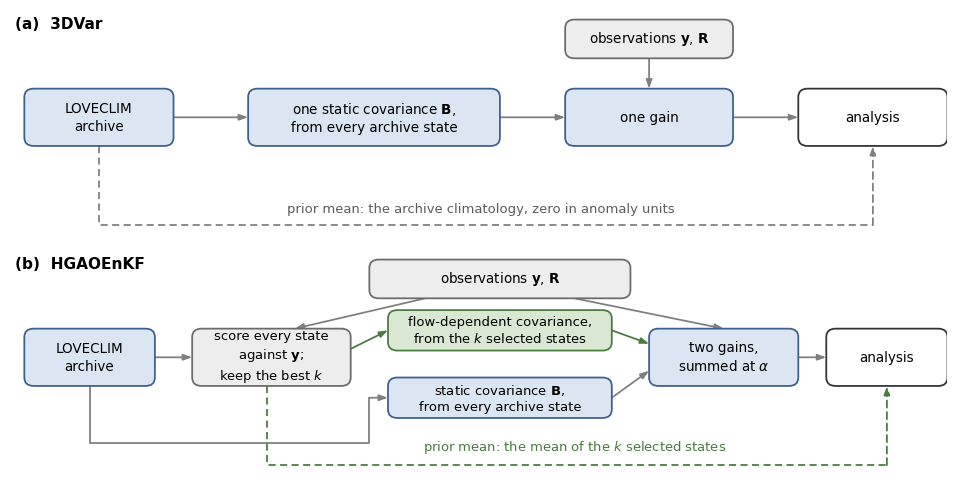

In [15]:
fig = diagrams.estimator_schematic()
save(fig, "fig05_01_estimator_schematic")

### Size of the inverted matrix

In [16]:
print(f"median observations per network: {int(np.median(recon['n_obs'][~recon['prior_only']]))}")

median observations per network: 174


### Table 5.1: the static covariance taper each lane selected

In [17]:
grid = (len(ppe_cfg["localization_grid"]), len(ppe_cfg["shrinkage_grid"]), len(ppe_cfg["alpha_grid"]))
print(f"{grid[0]} lengthscales x {grid[1]} shrinkages x {grid[2]} coupling factors = "
      f"{np.prod(grid)} covariances, at {len(ppe_cfg['b_scales'])} amplitudes")
pd.DataFrame([{"lane": LANE_NAME[lane], "L (km)": cfg["selected"]["localization_km"],
               "lambda": cfg["selected"]["shrinkage_lambda"], "gamma": cfg["selected"]["alpha"],
               "c": cfg["selected"]["b_scale"]}
              for lane, cfg in zip(LANES, (ppe_cfg, traj_cfg, wh_cfg))]).set_index("lane")

7 lengthscales x 4 shrinkages x 5 coupling factors = 140 covariances, at 10 amplitudes


,L (km),lambda,gamma,c
lane,,,,
snapshot,20000.0,0.0,0.5,1.0
time series,20000.0,0.0,0.5,0.1
withholding,NaN,0.5,0.5,2.0


### Table 5.2: selection rules on the snapshot lane, at k = 60, alpha = 0.5, c = 5

In [18]:
rules = {"misfit, R-weighted": EST_HG, "correlation, pooled": "hgaoenkf_correlation",
         "correlation, per channel": "hgaoenkf_correlation_perchan"}
pd.Series({name: value(pooled(metrics(est, paths.LANE_PPE)), "rrmse", method=est, split="test",
                       analog_k=60, hybrid_w=0.5, b_scale=5.0, tendency_theta=0.0)
           for name, est in rules.items()}, name="test rRMSE")

misfit, R-weighted          0.6069
correlation, pooled         0.6155
correlation, per channel    0.6128
Name: test rRMSE, dtype: float64

### Figure 5.2: the lag correlation of the observation model (`fig05_02_lag_correlation`)

all cells, median rho at 175 yr: 0.81


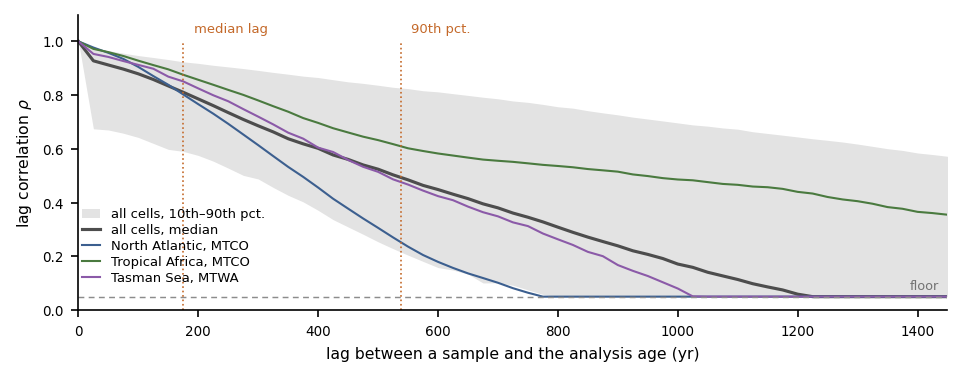

In [19]:
MEDIAN_LAG, P90_LAG = 175.0, 537.5
MARK = "#c4692a"
lag_axis, rho = stats.lag_correlation(cube, ages)


def flat_index(lat, lon, channel):
    i = int(np.argmin(np.abs(np.asarray(lats) - lat)))
    j = int(np.argmin(np.abs(np.asarray(lons) - lon)))
    return channel * N_CELLS + i * len(lons) + j


# The North Atlantic, where the archive renews fastest; a quiet tropical cell; and a
# mid-latitude Southern Hemisphere cell in the other channel.
SHOWN = [("North Atlantic, MTCO", flat_index(62, -20, 0), "#3c5f8f"),
         ("Tropical Africa, MTCO", flat_index(2, 20, 0), "#4a7a3f"),
         ("Tasman Sea, MTWA", flat_index(-40, 145, 1), "#8b5aa8")]

fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 2.4), constrained_layout=True)
q10, q50, q90 = np.percentile(rho, [10, 50, 90], axis=1)
ax.fill_between(lag_axis, q10, q90, color="0.89", lw=0, label="all cells, 10th–90th pct.")
ax.plot(lag_axis, q50, color="0.30", lw=1.5, label="all cells, median")
for name, idx, colour in SHOWN:
    ax.plot(lag_axis, rho[:, idx], color=colour, lw=1.0, label=name)
ax.axhline(stats.RHO_FLOOR, color="0.55", lw=0.7, ls=(0, (4, 3)))
ax.text(1435, stats.RHO_FLOOR + 0.015, "floor", color="0.45", fontsize=6.2, ha="right",
        va="bottom")
for x, label in ((MEDIAN_LAG, "median lag"), (P90_LAG, "90th pct.")):
    ax.plot([x, x], [0, 1.0], color=MARK, lw=0.8, ls=":")
    ax.text(x + 18, 1.045, label, color=MARK, fontsize=6.3, va="center", ha="left")
ax.set_xlim(0, 1450)
ax.set_ylim(0, 1.10)
ax.set_xlabel("lag between a sample and the analysis age (yr)")
ax.set_ylabel(r"lag correlation $\rho$")
ax.legend(loc="lower left", frameon=False, handlelength=1.4, borderpad=0.1,
          labelspacing=0.22, fontsize=6.3, bbox_to_anchor=(-0.005, 0.06))
save(fig, "fig05_02_lag_correlation")

print(f"all cells, median rho at {MEDIAN_LAG:.0f} yr: {np.interp(MEDIAN_LAG, lag_axis, q50):.2f}")

### Pairs behind the spatial error variance

In [20]:
rep_cell = obs_cell_index(long["lat"].to_numpy(), long["lon"].to_numpy(),
                          long["channel"].to_numpy(), lats, lons) % N_CELLS
for channel, (n_pairs, n_sites, n_cells) in stats.representativeness_pairs(long, rep_cell).items():
    print(f"{channel}: {n_pairs:,} pairs from {n_sites} sites in {n_cells} cells")

mtco: 19,145 pairs from 104 sites in 40 cells
mtwa: 19,145 pairs from 104 sites in 40 cells


### Table 5.3: the observation model on the withholding lane, 3DVar

In [21]:
M = pooled(ablation_metrics("rep_var"))
arms = {"sse only": "3dvar_sse", "+ spatial": "3dvar_sse_rep",
        "+ temporal": "3dvar_sse_temporal_temporal_deflate",
        "+ both": "3dvar_sse_rep_temporal_temporal_deflate"}
rows = []
for name, method in arms.items():
    c, sel_rrmse = selected_by_amplitude(M, method=method)
    rows.append({"observation error": name, "c": c, "sel. rRMSE": sel_rrmse,
                 "rRMSE": value(M, "rrmse", method=method, split="test", b_scale=c)})
pd.DataFrame(rows).set_index("observation error")

,c,sel. rRMSE,rRMSE
observation error,,,
sse only,1.0,0.9637,0.9613
+ spatial,2.0,0.9626,0.9607
+ temporal,1.0,0.9590,0.9565
+ both,2.0,0.9582,0.9563


## Chapter 6: Multiscale Tendency Augmentation

### Table 6.1: HGAOEnKF's gain over 3DVar on the snapshot lane (k = 60)

In [22]:
b3 = config(EST_3DVAR, paths.LANE_PPE)["selected"]["b_scale"]
rows = [{"algorithm": "3DVar", "gain": "static B", "c": b3,
         "rRMSE": operating_point(EST_3DVAR, paths.LANE_PPE)["rrmse"]}]
Mh = pooled(metrics(EST_HG, paths.LANE_PPE))
for w, gain in ((0.0, "static B (alpha = 0)"), (0.5, "hybrid (alpha = 0.5)")):
    c, _ = selected_by_amplitude(Mh, method=EST_HG, analog_k=60, hybrid_w=w)
    rows.append({"algorithm": "HGAOEnKF", "gain": gain, "c": c,
                 "rRMSE": value(Mh, "rrmse", method=EST_HG, split="test", analog_k=60,
                                hybrid_w=w, b_scale=c)})
pd.DataFrame(rows).set_index(["algorithm", "gain"])

c   rRMSE
algorithm gain                             
3DVar     static B              1.0  0.5903
HGAOEnKF  static B (alpha = 0)  1.0  0.5835
          hybrid (alpha = 0.5)  2.0  0.5889

### The whitened spectrum of the real networks

In [23]:
prior6, pool6, prior_idx6 = stats.trajectory_pool(
    cube, ages, lats, lons, valid, inherited_taper(EST_MT, paths.LANE_TRAJECTORY))
traj_mt = run_artifact(EST_MT, paths.LANE_TRAJECTORY, "trajectory_analysis.npz")
spectra = stats.whitened_spectra(prior6, long, ages, lats, lons, traj_mt)
share = np.array([np.cumsum(np.sort(lam)[::-1])[[0, 4]] / lam.sum() for lam in spectra])
print(f"{len(spectra)} networks; median share of the whitened variance in the leading direction "
      f"{np.median(share[:, 0]):.2f}, in the first five {np.median(share[:, 1]):.2f}")

365 networks; median share of the whitened variance in the leading direction 0.60, in the first five 0.91


### Figure 6.1: the selection rules in whitened coordinates (`fig06_04_whitened_geometry`)

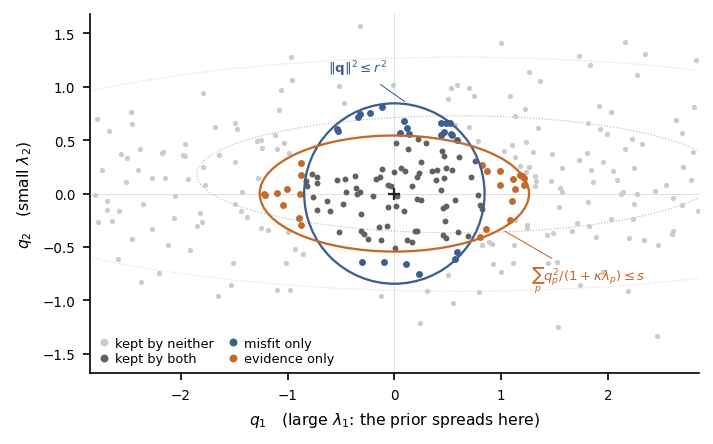

In [24]:
fig = diagrams.whitened_geometry()
save(fig, "fig06_04_whitened_geometry")

### Table 6.2: misfit and evidence rules at k = 60, alpha = 0.5, c = 1

In [25]:
fixed = dict(analog_k=60, hybrid_w=0.5, b_scale=1.0, tendency_theta=0.0)
rows = {}
for name, est in (("misfit", EST_HG), ("evidence", "hgaoenkf_evidence")):
    M = pooled(metrics(est, paths.LANE_PPE))
    rows[name] = {split: value(M, "rrmse", method=est, split=split, **fixed)
                  for split in ("selection", "test")}
table = pd.DataFrame(rows).T
print(f"test rRMSE improvement: {100 * (1 - table.loc['evidence', 'test'] / table.loc['misfit', 'test']):.2f}%")
table

test rRMSE improvement: 2.42%


,selection,test
misfit,0.5901,0.5918
evidence,0.5741,0.5775


### Figure 6.2: response of the tendency stack (`fig06_02_stack_response`)

stack response at 195 yr: 0.502 of its peak
stack response at 200 yr: 0.085 of its peak
stack response at 205 yr: 0.498 of its peak


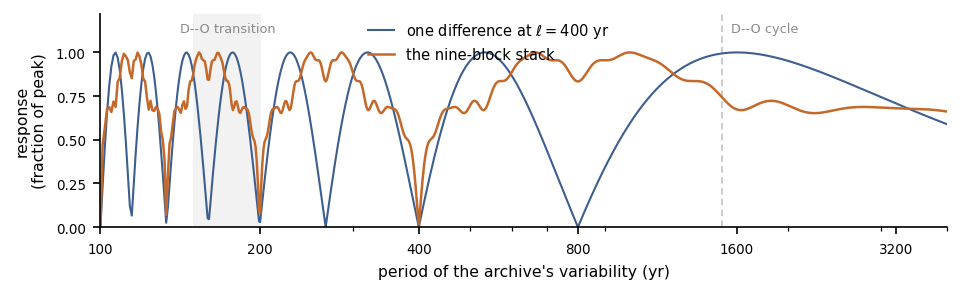

In [26]:
mt6 = stats.mta_stack(pool6, ages[prior_idx6], lats, lons)
T6 = np.linspace(100.0, 4000.0, 4000)
response, one_lag = stats.stack_response(mt6, T6)

fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 1.85), constrained_layout=True)
ax.axvspan(150, 200, color="#f2f2f2", zorder=0)
ax.axvline(1500, color="#c4c4c4", lw=0.8, ls=(0, (4, 2.5)), zorder=0)
ax.plot(T6, one_lag, lw=1.0, color="#3c5f8f", label=r"one difference at $\ell = 400$ yr")
ax.plot(T6, response, lw=1.2, color="#c4692a", label="the nine-block stack")
ax.set_xscale("log"); ax.set_xlim(100, 4000); ax.set_ylim(0, 1.22)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticks([100, 200, 400, 800, 1600, 3200])
ax.set_xticklabels(["100", "200", "400", "800", "1600", "3200"])
ax.set_xlabel("period of the archive's variability (yr)")
ax.set_ylabel("response\n(fraction of peak)")
ax.text(174, 1.10, "D--O transition", fontsize=6.2, color="#8a8a8a", ha="center", va="bottom")
ax.text(1560, 1.10, "D--O cycle", fontsize=6.2, color="#8a8a8a", ha="left", va="bottom")
ax.legend(loc="upper left", frameon=False, handlelength=1.8, bbox_to_anchor=(0.30, 1.03))
save(fig, "fig06_02_stack_response")

for period in (195, 200, 205):
    print(f"stack response at {period} yr: {np.interp(period, T6, response):.3f} of its peak")

### Figure 6.3: MTA-HGAOEnKF (`fig06_03_estimator_schematic`)

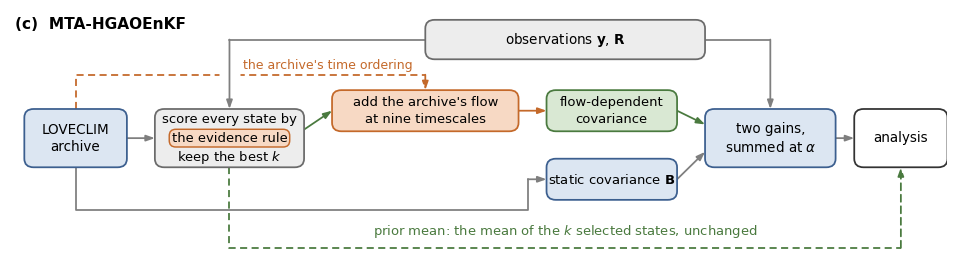

In [27]:
fig = diagrams.mta_schematic()
save(fig, "fig06_03_estimator_schematic")

### Table 6.3: MTA measured in progressions, k = 100, alpha = 1

In [28]:
def stack_row(M, name, **cols):
    c, sel_rrmse = selected_by_amplitude(M, **cols)
    test = {m: value(M, m, split="test", b_scale=c, **cols) for m in ("rrmse", "ce", "amplitude")}
    return {"stack": name, "c": c, "sel. rRMSE": sel_rrmse, "test rRMSE": test["rrmse"],
            "test CE": test["ce"], "amplitude": test["amplitude"]}


Mmt = pooled(metrics(EST_MT, paths.LANE_PPE))
Mstack = pooled(ablation_metrics("mt_stack"))
rows = [stack_row(Mmt, "no augmentation (theta = 0)", method=EST_MT, analog_k=100,
                  hybrid_w=1.0, tendency_theta=0.0)]
for name, label in (("1lag", "one lag (400)"), ("3lag", "three lags (400, 800, 1600)"),
                    ("7lag", "seven lags"), ("7lag_curv", "seven lags + 2nd order")):
    rows.append(stack_row(Mstack, label, method=ex.mt_stack_estimator(name)))
pd.DataFrame(rows).set_index("stack")

,c,sel. rRMSE,test rRMSE,test CE,amplitude
stack,,,,,
no augmentation (theta = 0),1.0,0.5740,0.5783,0.6655,0.7989
one lag (400),2.0,0.5621,0.5632,0.6828,0.8260
"three lags (400, 800, 1600)",2.0,0.5571,0.5584,0.6882,0.8220
seven lags,2.0,0.5535,0.5552,0.6918,0.8206
seven lags + 2nd order,2.0,0.5507,0.5531,0.6941,0.8202


## Chapter 7: Evaluation

### Table 7.1: the operating point of each estimator

In [29]:
mt_cfg = config(EST_MT, paths.LANE_PPE)
rows = []
for lane in LANES:
    for est, label, *_ in ESTIMATORS:
        cfg = config(est, lane)
        sel = cfg["selected"]
        analog = config(est, paths.LANE_PPE)["selected"] if est != EST_3DVAR else {}
        rows.append({"lane": LANE_NAME[lane], "estimator": label,
                     "L (km)": sel.get("localization_km", cfg.get("localization_km")),
                     "lambda": sel.get("shrinkage_lambda", cfg.get("shrinkage_lambda")),
                     "gamma": sel.get("alpha", cfg.get("alpha")),
                     "k": analog.get("analog_k"), "alpha": analog.get("hybrid_w"),
                     "c": sel["b_scale"],
                     "sel. rRMSE": operating_point(est, lane, split="selection")["rrmse"]})
first = sorted([mt_cfg["selected"]["tendency_lag_yr"], *mt_cfg["tendency_extra_lags_yr"]])
print(f"MTA-HGAOEnKF: {mt_cfg['selection']} rule, kappa = {mt_cfg['evidence_scale']}; first "
      f"differences at {first} yr, second differences at {mt_cfg['tendency_curvature_yr']} yr")
pd.DataFrame(rows).set_index(["lane", "estimator"])

MTA-HGAOEnKF: evidence rule, kappa = 1.0; first differences at [200.0, 400.0, 800.0, 1200.0, 1600.0, 2400.0, 3200.0] yr, second differences at [400.0, 1600.0] yr


L (km)  lambda  gamma      k  alpha    c  \
lane        estimator                                                 
snapshot    3DVar         20000.0     0.0    0.5    NaN    NaN  1.0   
            HGAOEnKF      20000.0     0.0    0.5   60.0    0.0  1.0   
            MTA-HGAOEnKF  20000.0     0.0    0.5  100.0    1.0  2.0   
time series 3DVar         20000.0     0.0    0.5    NaN    NaN  0.1   
            HGAOEnKF      20000.0     0.0    0.5   60.0    0.0  0.3   
            MTA-HGAOEnKF  20000.0     0.0    0.5  100.0    1.0  0.3   
withholding 3DVar             NaN     0.5    0.5    NaN    NaN  2.0   
            HGAOEnKF          NaN     0.5    0.5   60.0    0.0  1.0   
            MTA-HGAOEnKF      NaN     0.5    0.5  100.0    1.0  2.0   

                          sel. rRMSE  
lane        estimator                 
snapshot    3DVar             0.5903  
            HGAOEnKF          0.5818  
            MTA-HGAOEnKF      0.5507  
time series 3DVar             0.7646  
            HGAOEnKF          0.7793  
            MTA-HGAOEnKF      0.7637  
withholding 3DVar             0.9582  
            HGAOEnKF          0.9606  
            MTA-HGAOEnKF      0.9603

### Table 7.2: test-split skill

In [30]:
rows = []
for lane in LANES:
    for m in ("nearest", "idw"):
        rows.append({"lane": LANE_NAME[lane], "estimator": m, **references[lane][m]})
    for est, label, *_ in ESTIMATORS:
        rows.append({"lane": LANE_NAME[lane], "estimator": label,
                     **operating_point(est, lane)[["rrmse", "ce", "amplitude"]],
                     "ssim": operating_point(est, lane).get("ssim", np.nan)})
pd.DataFrame(rows).set_index(["lane", "estimator"])[["rrmse", "ce", "amplitude", "ssim"]]

rrmse      ce  amplitude    ssim
lane        estimator                                      
snapshot    nearest       1.5384 -1.3668     1.5335  0.1584
            idw           0.8948  0.1993     0.5945  0.3312
            3DVar         0.5903  0.6515     0.8047  0.6574
            HGAOEnKF      0.5835  0.6596     0.8629  0.6655
            MTA-HGAOEnKF  0.5531  0.6941     0.8202  0.6719
time series nearest       1.5846 -1.5027     1.4694  0.1378
            idw           0.9476  0.1051     0.4967  0.3179
            3DVar         0.6981  0.5143     0.6268  0.5792
            HGAOEnKF      0.6794  0.5399     0.9140  0.6278
            MTA-HGAOEnKF  0.6742  0.5470     0.8197  0.6272
withholding nearest       1.2081 -0.4595     0.9428     NaN
            idw           1.0205 -0.0413     0.6381     NaN
            3DVar         0.9563  0.0854     0.3196     NaN
            HGAOEnKF      0.9582  0.0819     0.3205     NaN
            MTA-HGAOEnKF  0.9587  0.0810     0.3119     NaN

### Resampling the scored units

Paired differences in CE with 95% intervals over 5,000 redraws: the 187 sites on the withholding
lane, the 402 truth states on the snapshot lane.

In [31]:
PAIRS = ((EST_MT, EST_3DVAR), (EST_HG, EST_3DVAR), (EST_MT, EST_HG))
LABEL = {est: label for est, label, *_ in ESTIMATORS}

wh = {est: run_artifact(est, paths.LANE_WITHHOLDING, "withholding_random_predictions.npz")
      for est in (EST_3DVAR, EST_HG, EST_MT)}
truth_wh, site_wh = wh[EST_3DVAR]["actual"], wh[EST_3DVAR]["site"]
assert all(np.array_equal(wh[e]["actual"], truth_wh) and np.array_equal(wh[e]["site"], site_wh)
           for e in wh)
pred_wh = {}
for est, z in wh.items():
    j = int(np.argmin(np.abs(z["b_scales"] - config(est, paths.LANE_WITHHOLDING)["selected"]["b_scale"])))
    pred_wh[est] = z[f"climatological_pred_{ex.method_label(est, ex.TEMPORAL_DEFLATE)}"][j]

snap = {est: run_artifact(est, paths.LANE_PPE, "ppe_analysis.npz") for est in (EST_3DVAR, EST_HG, EST_MT)}
truth_snap = snap[EST_3DVAR]["truth_anom"]
assert all(np.array_equal(snap[e]["truth_anom"], truth_snap) for e in snap)
mask_snap = snap[EST_3DVAR]["safe_valid"]

rows = []
for better, worse in PAIRS:
    for lane, (d, lo, hi) in (
            ("withholding", stats.site_bootstrap_dce(truth_wh, pred_wh[better], pred_wh[worse], site_wh)),
            ("snapshot", stats.truth_bootstrap_dce(truth_snap, snap[better]["recon_climatological"],
                                                   snap[worse]["recon_climatological"], mask_snap))):
        rows.append({"lane": lane, "pair": f"{LABEL[better]} - {LABEL[worse]}",
                     "dCE": d, "2.5%": lo, "97.5%": hi, "clears zero": lo > 0 or hi < 0})
pd.DataFrame(rows).set_index(["lane", "pair"]).sort_index()

dCE    2.5%   97.5%  clears zero
lane        pair                                                        
snapshot    HGAOEnKF - 3DVar         0.0081  0.0005  0.0153         True
            MTA-HGAOEnKF - 3DVar     0.0426  0.0336  0.0520         True
            MTA-HGAOEnKF - HGAOEnKF  0.0345  0.0241  0.0455         True
withholding HGAOEnKF - 3DVar        -0.0035 -0.0085  0.0017        False
            MTA-HGAOEnKF - 3DVar    -0.0045 -0.0123  0.0034        False
            MTA-HGAOEnKF - HGAOEnKF -0.0009 -0.0047  0.0035        False

### Figure 7.1: test rRMSE against the hybrid weight (`fig07_01_hybrid_weight`)

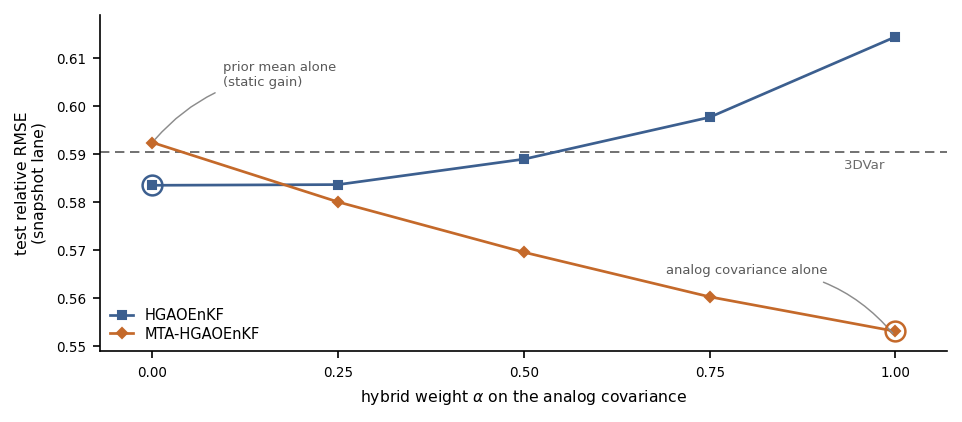

In [32]:
def alpha_profile(estimator, theta):
    """Test rRMSE at each weight, at the k and c that weight's own selection split prefers."""
    M = pd.read_csv(paths.run_dir(estimator, paths.LANE_PPE) / "metrics.csv")
    base = ((M.method == ex.method_label(estimator)) & (M.lane == ex.LANE_PPE)
            & (M.channel == "pooled") & (M.do_event == "all") & (M.metric == "rrmse")
            & np.isclose(M.tendency_theta, theta))
    sel, tst = M[base & (M.split == "selection")], M[base & (M.split == "test")]
    rows = []
    for w, g in sel.groupby("hybrid_w"):
        win = g.loc[g.value.idxmin()]
        hit = tst[np.isclose(tst.hybrid_w, w) & np.isclose(tst.analog_k, win.analog_k)
                  & np.isclose(tst.b_scale, win.b_scale)]
        rows.append((float(w), float(hit.value.iloc[0]), int(win.analog_k), float(win.b_scale)))
    return np.array(sorted(rows))


three_rrmse = operating_point(EST_3DVAR, paths.LANE_PPE)["rrmse"]
fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 2.7), constrained_layout=True)
ax.axhline(three_rrmse, color="#6b6b6b", lw=0.9, ls=(0, (5, 3)), zorder=1)
ax.text(0.985, three_rrmse - 0.0012, "3DVar", color="#6b6b6b", fontsize=6.4,
        ha="right", va="top")
for estimator, label, colour, marker in ESTIMATORS[1:]:
    cfg = config(estimator, paths.LANE_PPE)
    theta = cfg["selected"]["tendency_theta"]
    prof = alpha_profile(estimator, theta)
    ax.plot(prof[:, 0], prof[:, 1], marker + "-", ms=3.6, lw=1.3, color=colour, label=label,
            zorder=3)
    chosen = float(cfg["selected"]["hybrid_w"])
    y = float(prof[np.isclose(prof[:, 0], chosen), 1][0])
    ax.plot([chosen], [y], marker="o", ms=9.5, mfc="none", mec=colour, mew=1.2, zorder=4)
ax.annotate("prior mean alone\n(static gain)", xy=(0.0, 0.5924), xytext=(0.095, 0.6065),
            fontsize=6.3, color="0.35", ha="left", va="center",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.55",
                            connectionstyle="arc3,rad=0.2"))
ax.annotate("analog covariance alone", xy=(1.0, 0.552), xytext=(0.80, 0.5645),
            fontsize=6.3, color="0.35", ha="center", va="bottom",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.55",
                            connectionstyle="arc3,rad=-0.25"))
ax.set_xlim(-0.07, 1.07)
ax.set_ylim(0.549, 0.619)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel(r"hybrid weight $\alpha$ on the analog covariance")
ax.set_ylabel("test relative RMSE\n(snapshot lane)")
ax.legend(loc="lower left", frameon=False, handlelength=1.6, borderpad=0.15,
          labelspacing=0.25)
save(fig, "fig07_01_hybrid_weight")

### Figure 7.2: CE against the background amplitude (`fig07_06_amplitude_sweep`)

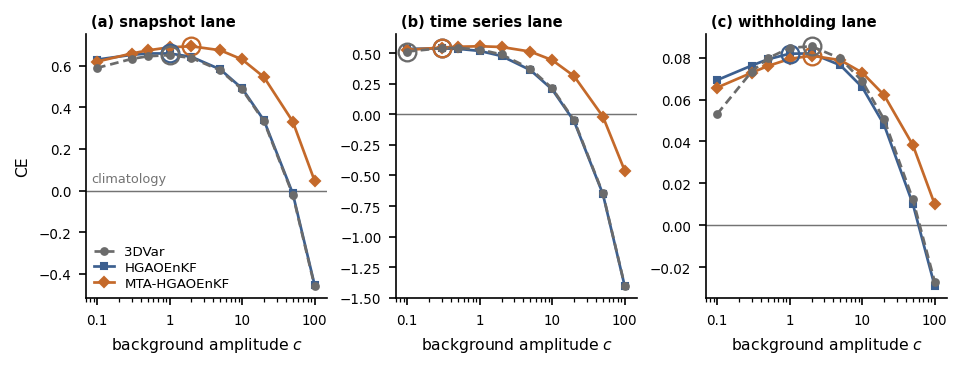

In [33]:
# Only c varies along a curve; everything else is held at the lane's selected configuration.
SWEEP = (("a", "snapshot", paths.LANE_PPE, ex.LANE_PPE, ex.TEMPORAL_OFF, False),
         ("b", "time series", paths.LANE_TRAJECTORY, ex.LANE_TRAJECTORY, ex.TEMPORAL_DEFLATE, False),
         ("c", "withholding", paths.LANE_WITHHOLDING, "withholding_random", ex.TEMPORAL_DEFLATE, True))

fig, axes = plt.subplots(1, 3, figsize=(REPORT_WIDTH, 2.35), constrained_layout=True)
for ax, (tag, title, dirname, lanecol, treat, by_fold) in zip(axes, SWEEP):
    for estimator, label, colour, marker in ESTIMATORS:
        cfg = config(estimator, dirname)
        M = metrics(estimator, dirname)
        m = ((M.method == ex.method_label(estimator, treat)) & (M.lane == lanecol)
             & (M.split == "test") & (M.channel == "pooled") & (M.do_event == "all")
             & (M.metric == "ce"))
        if by_fold:
            m &= (M.fold == -1)
        sel = cfg["selected"]
        for key in ("localization_km", "shrinkage_lambda", "alpha"):
            v = sel.get(key, cfg.get(key))
            m &= M[key].isna() if v is None else np.isclose(M[key], v)
        for key in ("analog_k", "hybrid_w") + ex.TERM_KEYS:
            if key in sel and M[key].notna().any():
                m &= np.isclose(M[key], sel[key])
        curve = M[m].set_index("b_scale")["value"].sort_index()
        static = estimator == EST_3DVAR
        ax.plot(curve.index, curve.values, marker=marker, ms=3.2, lw=1.3, color=colour,
                ls=(0, (3.2, 1.8)) if static else "-", label=label,
                zorder=5 if static else 3)
        b = sel["b_scale"]
        ax.plot([b], [curve.loc[b]], marker="o", ms=8.5, mfc="none", mec=colour, mew=1.1,
                zorder=6 if static else 4)
    ax.axhline(0.0, color="0.45", lw=0.7)
    ax.set_xscale("log")
    ax.set_xlim(0.07, 150)
    ax.set_xticks([0.1, 1, 10, 100])
    ax.set_xticklabels(["0.1", "1", "10", "100"])
    ax.set_xlabel(r"background amplitude $c$")
    ax.text(0.02, 1.02, f"({tag}) {title} lane", transform=ax.transAxes, fontsize=7.0,
            fontweight="bold", va="bottom")
axes[0].set_ylabel("CE")
axes[0].text(0.082, 0.025, "climatology", fontsize=6.2, color="0.45", ha="left",
             va="bottom")
axes[0].legend(loc="lower left", frameon=False, handlelength=1.5, borderpad=0.1,
               labelspacing=0.22, fontsize=6.4)
save(fig, "fig07_06_amplitude_sweep")

### Figure 7.3: skill against distance to data, snapshot lane (`fig07_02_skill_vs_distance`)

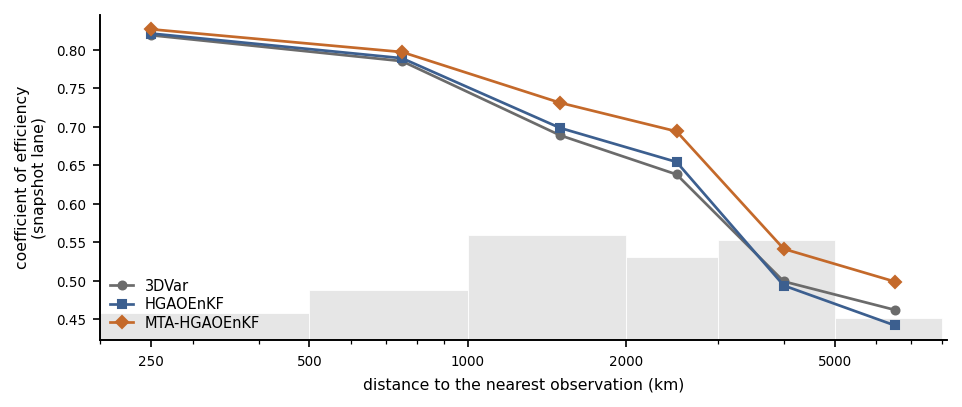

In [34]:
fig, ax = plt.subplots(figsize=(REPORT_WIDTH, 2.6), constrained_layout=True)
for estimator, label, colour, marker in ESTIMATORS:
    cfg = config(estimator, paths.LANE_PPE)
    z = run_artifact(estimator, paths.LANE_PPE, "ppe_skill_vs_distance.npz")
    bj = int(np.argmin(np.abs(z["b_scales"] - cfg["selected"]["b_scale"])))
    edges, counts = z["edges"], z["count"]
    # The outermost bin holds a few hundred points in the ocean voids, too few to draw.
    keep = counts > 1000 if (counts > 1000).any() else counts > 0
    ax.plot(stats.bin_centres(edges)[keep], z["ce"][bj][keep], marker + "-", ms=3.8, lw=1.3,
            color=colour, label=label, zorder=3)
    if estimator == EST_3DVAR:
        count_axis(ax, edges[:keep.sum() + 1], counts[keep] / 1e3)
ax.set_xscale("log")
ax.set_xlim(200, 8200)
ax.set_xticks([250, 500, 1000, 2000, 5000])
ax.set_xticklabels(["250", "500", "1000", "2000", "5000"])
ax.set_xlabel("distance to the nearest observation (km)")
ax.set_ylabel("coefficient of efficiency\n(snapshot lane)")
ax.legend(loc="lower left", frameon=False, handlelength=1.6, borderpad=0.15,
          labelspacing=0.25)
save(fig, "fig07_02_skill_vs_distance")

### Figure 7.4: per-cell CE, snapshot lane (`fig07_03_percell_ce`)

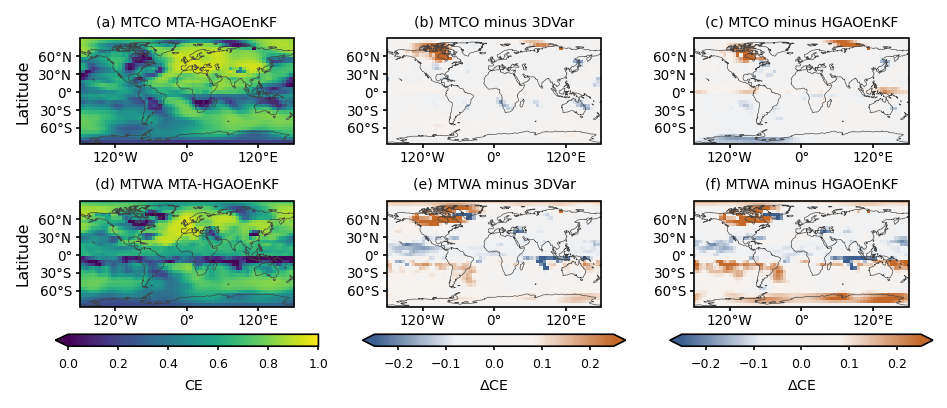

In [35]:
ref = snap[EST_3DVAR]
lats7, lons7 = ref["lats"], ref["lons"]
truth7 = ref["truth_anom"].astype(np.float64)
zero7 = np.zeros_like(truth7[0])
ce = {e: da.ce_map(truth7, snap[e]["recon_climatological"].astype(np.float64), zero7)
      for e in snap}
mt_ce = ce[EST_MT]
# Clipped just past the 98th percentile of the difference: cells where the truth barely varies
# reach several CE units and would flatten everything else.
DIFF_LIM = 0.25
COLS = [("MTA-HGAOEnKF", mt_ce, dict(vmin=0.0, vmax=1.0, cmap="viridis"), "min", "CE"),
        ("minus 3DVar", mt_ce - ce[EST_3DVAR],
         dict(vmin=-DIFF_LIM, vmax=DIFF_LIM, cmap=DIFF_CMAP), "both", r"$\Delta$CE"),
        ("minus HGAOEnKF", mt_ce - ce[EST_HG],
         dict(vmin=-DIFF_LIM, vmax=DIFF_LIM, cmap=DIFF_CMAP), "both", r"$\Delta$CE")]

fig, axes = plt.subplots(2, 3, figsize=(REPORT_WIDTH, 2.60),
                         subplot_kw={"projection": PLATE}, constrained_layout=True)
for j, (label, field, kw, extend, unit) in enumerate(COLS):
    for c, name in enumerate(VARS):
        mesh = draw_field(axes[c, j], lats7, lons7, field[c], **kw)
        axes[c, j].set_title(f"({'adbecf'[2 * j + c]}) {name.upper()} {label}", fontsize=6.8)
        map_axes(axes[c, j], ylabel=(j == 0))
    cb = fig.colorbar(mesh, ax=axes[:, j], orientation="horizontal", shrink=0.92, pad=0.02,
                      aspect=22, extend=extend)
    cb.set_label(unit, fontsize=6.8)
    cb.ax.tick_params(labelsize=6, length=2)
save(fig, "fig07_03_percell_ce")

### Figure 7.5: skill by timescale, time-series lane (`fig07_04_timescale`)

,3DVar,HGAOEnKF,MTA-HGAOEnKF,MTA - HGAOEnKF
band CE,,,,
25-100 yr,-0.0763,-0.5589,-0.3849,0.1740
100-250 yr,-0.0104,-0.2565,-0.2089,0.0476
250-500 yr,0.2266,0.0657,0.1247,0.0590
500-1000 yr,0.5639,0.5143,0.5715,0.0572
1000-2000 yr,0.7074,0.6920,0.7683,0.0763


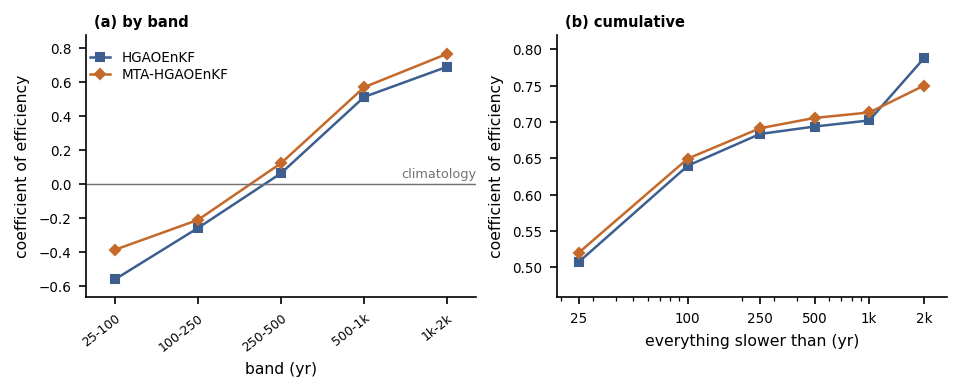

In [36]:
band_x = np.arange(len(ex.BANDS), dtype=float)
windows = np.array(ex.LOWPASS_WINDOWS, dtype=float)
band_ce = {}
fig, axes = plt.subplots(1, 2, figsize=(REPORT_WIDTH, 2.5), constrained_layout=True)
for estimator, label, colour, marker in ESTIMATORS:
    b = config(estimator, paths.LANE_TRAJECTORY)["selected"]["b_scale"]
    rows = lane_rows(estimator, paths.LANE_TRAJECTORY, ex.LANE_TRAJECTORY,
                     method=ex.method_label(estimator, ex.TEMPORAL_DEFLATE),
                     b_scale=b).set_index("metric")["value"]
    band_ce[estimator] = np.array([float(rows.get(f"ce_bp{lo}_{hi}", np.nan)) for lo, hi in ex.BANDS])
    lp_ce = np.array([float(rows.get(f"ce_lp{int(w)}", np.nan)) for w in windows])
    # The panel isolates what the stack does to the scheme it extends, so 3DVar is not drawn.
    if estimator != EST_3DVAR:
        kw = dict(ms=3.4, lw=1.2, color=colour)
        axes[0].plot(band_x, band_ce[estimator], marker + "-", label=label, **kw)
        axes[1].plot(windows, lp_ce, marker + "-", label=label, **kw)
axes[0].axhline(0.0, color="0.45", lw=0.7)
axes[0].text(4.35, 0.02, "climatology", fontsize=6.2, color="0.45", ha="right", va="bottom")
axes[0].set_ylim(-0.66, 0.88)
axes[0].set_ylabel("coefficient of efficiency")
axes[0].set_xlabel("band (yr)")
axes[0].text(0.02, 1.02, "(a) by band", transform=axes[0].transAxes, fontsize=7.0,
             fontweight="bold", va="bottom")
axes[0].legend(loc="upper left", frameon=False, handlelength=1.5, borderpad=0.1,
               labelspacing=0.22, fontsize=6.5, bbox_to_anchor=(-0.01, 0.97))
axes[1].set_ylim(0.46, 0.82)
axes[1].set_ylabel("coefficient of efficiency")
axes[1].set_xlabel("everything slower than (yr)")
axes[1].text(0.02, 1.02, "(b) cumulative", transform=axes[1].transAxes, fontsize=7.0,
             fontweight="bold", va="bottom")
axes[0].set_xlim(-0.35, len(ex.BANDS) - 0.65)
axes[0].set_xticks(band_x)
axes[0].set_xticklabels(["25-100", "100-250", "250-500", "500-1k", "1k-2k"], fontsize=6.0,
                        rotation=38, ha="right", rotation_mode="anchor")
axes[1].set_xscale("log")
axes[1].set_xlim(19, 2700)
axes[1].set_xticks([25, 100, 250, 500, 1000, 2000])
axes[1].set_xticklabels(["25", "100", "250", "500", "1k", "2k"])
save(fig, "fig07_04_timescale")

pd.DataFrame({LABEL[e]: band_ce[e] for e in band_ce} | {"MTA - HGAOEnKF": band_ce[EST_MT] - band_ce[EST_HG]},
             index=[f"{lo}-{hi} yr" for lo, hi in ex.BANDS]).rename_axis("band CE")

### Table 7.3: test-split calibration

In [37]:
pd.DataFrame({(LANE_NAME[lane], name): {label: operating_point(est, lane)[metric]
                                        for est, label, *_ in ESTIMATORS}
              for lane in LANES for name, metric in (("CRPS", "crps"), ("RCRV", "rcrv_dispersion"))})

snapshot         time series         withholding        
                 CRPS    RCRV        CRPS    RCRV        CRPS    RCRV
3DVar          0.2899  1.2066      0.3769  2.9680      1.0641  1.3883
HGAOEnKF       0.3001  2.0266      0.3628  3.2605      1.0707  1.5461
MTA-HGAOEnKF   0.2820  1.6856      0.3587  3.4452      1.0693  1.5150

## Chapter 8: The MIS3 reconstruction

In [38]:
B_REFERENCE = 5.0          # the member the maps and tables are quoted at
b_scales = recon["b_scales"]
bi = int(np.argmin(np.abs(b_scales - B_REFERENCE)))
b_ref = float(b_scales[bi])
prior_only = recon["prior_only"]
scored = ~prior_only
step_yr = float(inp.recon_cfg["step_yr"])
sim = cube.astype(np.float64) - recon["clim_mean"]
post = recon["mean_anom"].astype(np.float64)
w = stats.area_weights(lats, lons)
net = np.broadcast_to(np.asarray(lats, float)[:, None] > stats.NET_LAT, (len(lats), len(lons)))
net_w = np.where(net, w, 0.0)
onsets = [a for a in sorted(DO_ONSET_BP.values()) if ages.min() <= a <= ages.max()]
site_xy = long.groupby("site")[["lat", "lon"]].first()
structure = temporal_structure_function(cube, np.arange(len(ages)),
                                        max_lag=int(inp.recon_cfg["max_block_lag_steps"]))
at_grid = stats.proxy_rows_on_grid(long, ages, lats, lons, structure, step_yr)
comp_p, comp_s = stats.do_composite(post[bi], ages, onsets), stats.do_composite(sim, ages, onsets)


def at_site(field):
    return stats.at_site(field, len(lons))

### Table 8.1: contents of `reconstruction_fields.npz`

In [39]:
IN_TABLE = {"ages", "lats", "lons", "b_scales", "mean_anom", "post_var", "post_cross_var",
            "clim_mean", "prior_var", "n_obs", "n_sites", "prior_only"}
print(f"assimilated rows {int(recon['n_obs'].sum()):,}; sites per age median "
      f"{int(np.median(recon['n_sites'][scored]))}, range {int(recon['n_sites'][scored].min())}-"
      f"{int(recon['n_sites'].max())}; {int(prior_only.sum())} ages with no pollen; "
      f"amplitudes {[float(b) for b in b_scales]}")
pd.DataFrame([{"array": k, "shape": recon[k].shape, "dtype": str(recon[k].dtype),
               "in Table 8.1": k in IN_TABLE} for k in recon.files]).set_index("array")

assimilated rows 127,646; sites per age median 87, range 4-118; 36 ages with no pollen; amplitudes [0.3, 1.0, 2.0, 5.0, 10.0]


,shape,dtype,in Table 8.1
array,,,
ages,"(804,)",int64,True
lats,"(32,)",float32,True
lons,"(64,)",float32,True
safe_valid,"(32, 64)",bool,False
clim_mean,"(2, 32, 64)",float64,True
prior_var,"(2, 32, 64)",float64,True
b_scales,"(5,)",float64,True
mean_anom,"(5, 804, 2, 32, 64)",float32,True
post_var,"(5, 804, 2, 32, 64)",float32,True


### Table 8.2: the configuration the reconstruction was run at

In [40]:
rc = inp.recon_cfg
pd.Series({
    "analog selection": f"{mt_cfg['selection']} rule, kappa = {mt_cfg['evidence_scale']}",
    "ensemble size k": f"{rc['analog_k']:g}",
    "hybrid weight alpha": f"{rc['hybrid_w']:g}",
    "first differences (yr)": ", ".join(f"{x:g}" for x in first),
    "second differences (yr)": ", ".join(f"{x:g}" for x in mt_cfg["tendency_curvature_yr"]),
    "theta": f"{rc['tendency_theta']:g}, trace preserved: {bool(rc['preserve_obs_trace'])}",
    "taper L, lambda, gamma": f"{rc['localization_km']:g} km, {rc['shrinkage_lambda']:g}, "
                              f"{rc['alpha']:g}",
    "temporal term": rc["temporal_mode"],
    "spatial error variance": ", ".join(f"{k} {v:.2f}" for k, v in rc["rep_var_full"].items()),
    "amplitudes c": ", ".join(f"{x:g}" for x in rc["b_scales"]),
}, name="value").to_frame()

,value
analog selection,"evidence rule, kappa = 1.0"
ensemble size k,100
hybrid weight alpha,1
first differences (yr),"200, 400, 800, 1200, 1600, 2400, 3200"
second differences (yr),"400, 1600"
theta,"2, trace preserved: True"
"taper L, lambda, gamma","20000 km, 0, 0.5"
temporal term,deflate
spatial error variance,"mtco 0.70, mtwa 0.00"
amplitudes c,"0.3, 1, 2, 5, 10"


### Figure 8.1: the reconstruction against the simulation (`fig08_02_reconstruction_series`)

most variable cell: 73°N 22°E, no site
correlation of the product with the simulation, scored ages: c=0.3: 0.39, c=1: 0.39, c=2: 0.37, c=5: 0.34, c=10: 0.30


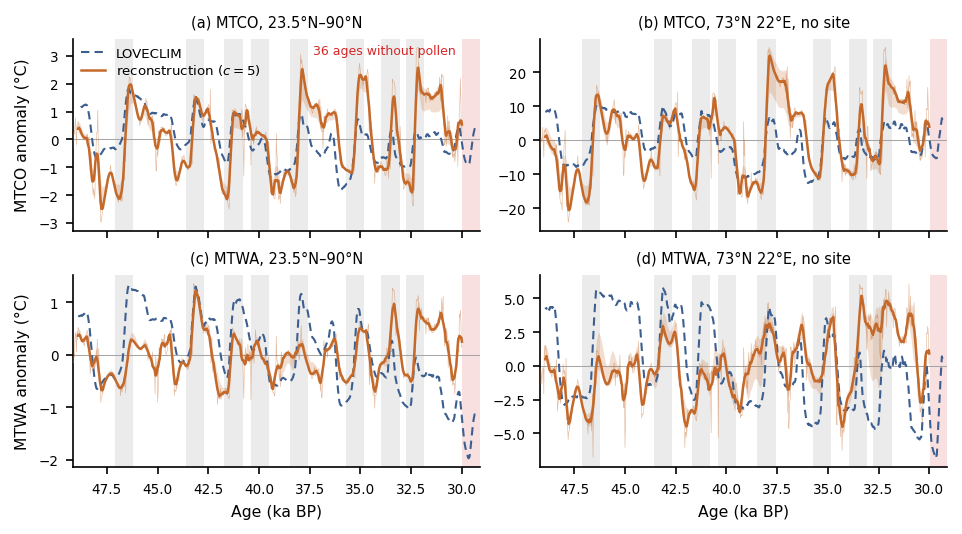

In [41]:
SMOOTH_YR = 250.0          # the fastest band the time-series lane beats a climatology over
# The archive's most variable cell, where the D-O signal lives.
hot = np.unravel_index(int(np.argmax(cube[:, 0].std(axis=0))), (len(lats), len(lons)))
hot_lon = ((float(lons[hot[1]]) + 180.0) % 360.0) - 180.0
hot_has_site = bool(reached[hot])
places = ((f"{stats.NET_LAT:g}°N–90°N", lambda f: stats.area_mean(f, net_w)),
          (f"{float(lats[hot[0]]):.0f}°N {abs(hot_lon):.0f}°"
           f"{'E' if hot_lon >= 0 else 'W'}"
           f"{'' if hot_has_site else ', no site'}", lambda f: f[..., hot[0], hot[1]]))
smooth = lambda s: da.lowpass_time(np.asarray(s, float)[:, None], SMOOTH_YR, step_yr)[:, 0]
# The low-pass zero-pads, so the ages it pulls towards zero at each end are not drawn.
trim = da.timescale_trim(SMOOTH_YR, step_yr)
edge = np.ones(len(ages), dtype=bool)
if trim:
    edge[:trim] = edge[-trim:] = False
shown = scored & edge
gap = np.where(shown, 1.0, np.nan)

fig, axes = plt.subplots(2, 2, figsize=(REPORT_WIDTH, 3.45), sharex=True,
                         constrained_layout=True)
for r, channel in enumerate(VARS):
    for c, (where, take) in enumerate(places):
        ax = axes[r, c]
        for o in onsets:
            ax.axvspan((o - stats.DO_POST_YR) / 1000, (o + stats.DO_PRE_YR) / 1000,
                       color="0.92", lw=0, zorder=0)
        band = np.array([smooth(take(post[j, :, r])) for j in range(len(b_scales))])
        sim_s, x = smooth(take(sim[:, r])), ages / 1000
        ax.axhline(0.0, color="0.65", lw=0.5, zorder=1)
        ax.fill_between(x, band.min(axis=0) * gap, band.max(axis=0) * gap, color=PRODUCT_C,
                        alpha=0.22, lw=0, zorder=2)
        ax.plot(x, take(post[bi, :, r]) * np.where(scored, 1.0, np.nan), color=PRODUCT_C,
                lw=0.3, alpha=0.45, zorder=3)
        ax.plot(x, sim_s * np.where(edge, 1.0, np.nan), color=SIM_C, lw=1.0,
                ls=(0, (4, 2.5)), zorder=4, label="LOVECLIM")
        ax.plot(x, band[bi] * gap, color=PRODUCT_C, lw=1.2, zorder=5,
                label=f"reconstruction ($c = {b_ref:g}$)")
        ax.set_title(f"({'acbd'[2 * c + r]}) {channel.upper()}, {where}", fontsize=7.0)
        if c == 0:
            ax.set_ylabel(f"{channel.upper()} anomaly (°C)")
        if r == len(VARS) - 1:
            ax.set_xlabel("Age (ka BP)")
axes[0, 0].legend(loc="upper left", frameon=False, handlelength=1.8, borderpad=0.1,
                  labelspacing=0.2, fontsize=6.4)
axes[0, 0].set_xlim(ages.max() / 1000, ages.min() / 1000)
if prior_only.any():
    for ax in axes.ravel():
        ax.axvspan(ages[prior_only].min() / 1000, ages[prior_only].max() / 1000,
                   color="C3", alpha=0.14, lw=0, zorder=0)
    axes[0, 0].annotate(f"{int(prior_only.sum())} ages without pollen",
                        xy=(ages[prior_only].max() / 1000, 0.97),
                        xycoords=("data", "axes fraction"), textcoords="offset points",
                        xytext=(-3, 0), fontsize=6.0, color="C3", ha="right", va="top")
save(fig, "fig08_02_reconstruction_series")

print(f"most variable cell: {places[1][0]}")
print("correlation of the product with the simulation, scored ages: "
      + ", ".join(f"c={float(bb):g}: {np.corrcoef(post[j][scored].ravel(), sim[scored].ravel())[0, 1]:.2f}"
                  for j, bb in enumerate(b_scales)))

### Figure 8.2: the reconstruction against LOVECLIM on withheld pollen (`fig08_03_evidence`)

held-out CE: product 0.079, LOVECLIM 0.028


,n rows,sites,dCE,2.5%,97.5%
rows,,,,,
all rows,127646,187,0.0507,0.0259,0.0753
different cell,80204,150,0.0315,0.0006,0.0644
> 250 km,86394,160,0.0408,0.0104,0.0727
> 500 km,57534,127,0.0260,-0.0113,0.0654
> 1000 km,27216,84,0.0324,-0.0324,0.0965


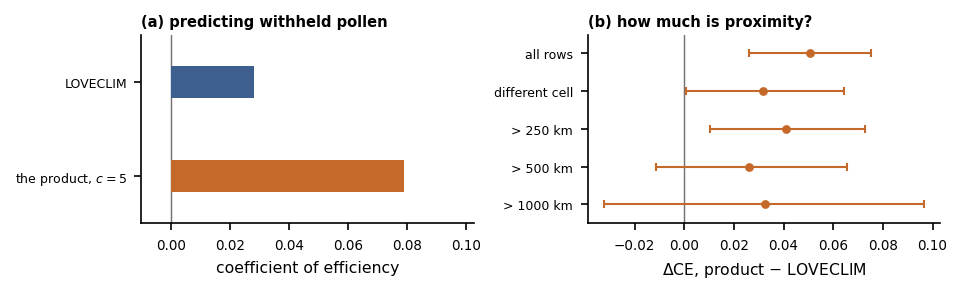

In [42]:
zw = wh[EST_MT]
truth = zw["actual"]
ident = stats.withheld_identity(long, ages, lats, lons, recon["safe_valid"],
                                config(EST_MT, paths.LANE_WITHHOLDING))
assert (len(ident) == len(truth) and np.allclose(ident["actual"].to_numpy(), truth)
        and np.array_equal(ident["site"].to_numpy(), zw["site"])
        and np.array_equal(ident["channel"].to_numpy(), zw["channel"])), "row identity not rebuilt"
wb = list(zw["b_scales"])
wj = int(np.argmin(np.abs(np.asarray(wb) - b_ref)))
product = zw[f"climatological_pred_{ex.method_label(EST_MT, ex.TEMPORAL_DEFLATE)}"][wj]
loveclim = stats.loveclim_at_sites(cube, ages, recon["clim_mean"], ident, structure, step_yr)
entries = [("LOVECLIM", loveclim, SIM_C),
           (f"the product, $c = {float(wb[wj]):g}$", product, PRODUCT_C)]
values = [stats.ce_against_climatology(truth, p) for _, p, _ in entries]

fig, axes = plt.subplots(1, 2, figsize=(REPORT_WIDTH, 1.85), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.0, 1.06]})
ypos = np.arange(len(entries), dtype=float)
axes[0].barh(ypos, values, height=0.34, color=[c for _, _, c in entries], zorder=3)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels([n for n, _, _ in entries], fontsize=6.0)
axes[0].set_ylim(len(entries) - 0.5, -0.5)
axes[0].set_xlabel("coefficient of efficiency")
axes[0].set_xlim(min(-0.01, 1.15 * min(values)), 1.30 * max(values))
axes[0].axvline(0.0, color="0.45", lw=0.7, zorder=2)
axes[0].text(0.0, 1.03, "(a) predicting withheld pollen", transform=axes[0].transAxes,
             fontsize=7.0, fontweight="bold", va="bottom")

cell_obs = ident["cell_observed"].to_numpy().astype(bool)
rows = []
for label, kind in stats.VOID_TESTS:
    m = stats.withheld_mask(kind, zw["distance_km"], cell_obs)
    if m.sum() < 50 or len(np.unique(zw["site"][m])) < 5:
        continue
    d, lo, hi = stats.site_bootstrap_dce(truth[m], product[m], loveclim[m], zw["site"][m])
    rows.append({"rows": label, "n rows": int(m.sum()), "sites": len(np.unique(zw["site"][m])),
                 "dCE": d, "2.5%": lo, "97.5%": hi})
cut = pd.DataFrame(rows)
ys = np.arange(len(cut), dtype=float)
axes[1].axvline(0.0, color="0.45", lw=0.7, zorder=1)
axes[1].errorbar(cut["dCE"], ys, xerr=[cut["dCE"] - cut["2.5%"], cut["97.5%"] - cut["dCE"]],
                 fmt="o", ms=3.2, lw=1.0, capsize=2.0, color=PRODUCT_C, zorder=3)
axes[1].set_yticks(ys)
axes[1].set_yticklabels(cut["rows"], fontsize=6.0)
axes[1].set_ylim(len(ys) - 0.5, -0.5)
axes[1].set_xlabel("$\\Delta$CE, product $-$ LOVECLIM")
axes[1].text(0.0, 1.03, "(b) how much is proximity?", transform=axes[1].transAxes,
             fontsize=7.0, fontweight="bold", va="bottom")
save(fig, "fig08_03_evidence")

print(f"held-out CE: product {values[1]:.3f}, LOVECLIM {values[0]:.3f}")
cut.set_index("rows")

### Table 8.3: interstadial minus stadial at the proxy sites north of 23.5°N

In [43]:
sources = {"LOVECLIM, at those cells": at_site(sim),
           "the pollen": lambda d: (d["y"] - d["my"]).to_numpy(),
           f"the reconstruction, c = {b_ref:g}": at_site(post[bi])}
rows = {}
for name, value_of in sources.items():
    dm = np.nanmean(stats.site_composite(at_grid, onsets, value_of), axis=0)
    rows[name] = {"dMTCO": dm[0], "dMTWA": dm[1], "ratio": dm[0] / dm[1]}
pd.DataFrame(rows).T

,dMTCO,dMTWA,ratio
"LOVECLIM, at those cells",0.8624,0.8167,1.0560
the pollen,1.4923,0.7034,2.1214
"the reconstruction, c = 5",1.7646,0.6955,2.5373


### Figure 8.3: the D-O composite (`fig08_04_do_composite`)

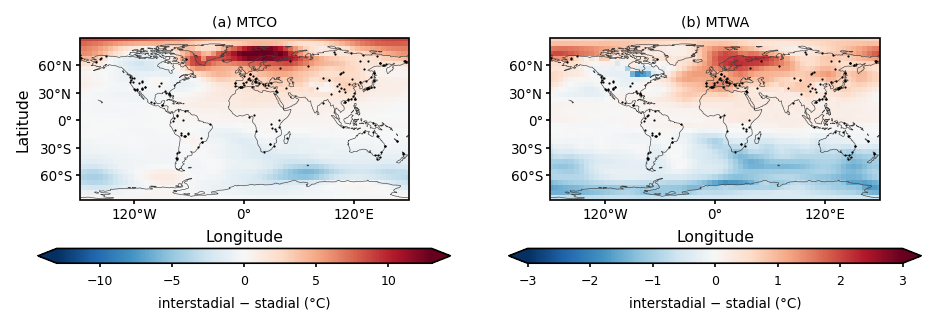

In [44]:
mean_p, mean_s = comp_p.mean(axis=0), comp_s.mean(axis=0)
fig, maps = plt.subplots(1, 2, figsize=(REPORT_WIDTH, 2.05), constrained_layout=True,
                         subplot_kw={"projection": PLATE})
# One scale per channel: the MTCO composite is several times larger than the MTWA one. Each is
# set at the field's 99.5th percentile, so no panel clips more than half a per cent.
for c, channel in enumerate(VARS):
    lim = float(np.ceil(np.percentile(np.abs(mean_p[c]), 99.5)))
    ax = maps[c]
    mesh = draw_field(ax, lats, lons, mean_p[c], vmin=-lim, vmax=lim, cmap="RdBu_r")
    ax.scatter(site_xy["lon"], site_xy["lat"], s=1.1, c="k", linewidth=0, transform=PLATE,
               zorder=3)
    map_axes(ax, xlabel=True, ylabel=(c == 0))
    ax.set_title(f"({'ab'[c]}) {channel.upper()}", fontsize=6.8)
    cb = fig.colorbar(mesh, ax=ax, orientation="horizontal", shrink=0.9, pad=0.02, aspect=28,
                      extend="both")
    cb.set_label("interstadial − stadial (°C)", fontsize=6.5)
    cb.ax.tick_params(labelsize=6, length=2)
save(fig, "fig08_04_do_composite")

### Regions: North America, the tropics and the peak warming

In [45]:
lon180 = ((at_grid["lon"] + 180.0) % 360.0) - 180.0
REGIONS = {"western North America": ((30, 62), (-170, -100)),
           "eastern North America": ((30, 62), (-100, -50))}
rows = []
for name, (lat_r, lon_r) in REGIONS.items():
    inside = ((at_grid["lat"] > lat_r[0]) & (at_grid["lat"] < lat_r[1])
              & (lon180 > lon_r[0]) & (lon180 < lon_r[1]))
    cells = stats.box_mask(lats, lons, lat_r, lon_r)
    grid = {"product": mean_p, "LOVECLIM": mean_s}
    rows.append({"region": name, "sites": at_grid[inside]["site"].nunique(),
                 **{f"sites {tag} dMTCO": np.nanmean(stats.site_composite(
                     at_grid[inside], onsets, value_of, min_lat=None), axis=0)[0]
                    for tag, value_of in (("pollen", sources["the pollen"]),
                                          ("LOVECLIM", at_site(sim)),
                                          ("product", at_site(post[bi])))},
                 **{f"grid {tag} dMTCO": stats.area_mean(field[0], np.where(cells, w, 0.0))
                    for tag, field in grid.items()}})
display(pd.DataFrame(rows).set_index("region").round(2))

tropics = at_grid[at_grid["lat"].abs() < stats.NET_LAT]
print(f"tropics, {tropics['site'].nunique()} sites:")
for tag, value_of in (("pollen", sources["the pollen"]), ("LOVECLIM", at_site(sim)),
                      ("product", at_site(post[bi]))):
    dm = np.nanmean(stats.site_composite(tropics, onsets, value_of, min_lat=None), axis=0)
    print(f"  {tag:9s} dMTCO {dm[0]:+.2f} dMTWA {dm[1]:+.2f}")

hottest = np.unravel_index(int(np.argmax(mean_p[0])), mean_p[0].shape)
print(f"peak composite dMTCO {mean_p[0][hottest]:+.2f} degC at {lats[hottest[0]]:.1f}N "
      f"{lons[hottest[1]]:.1f}E (LOVECLIM {mean_s[0][hottest]:+.2f}); a site in that cell: "
      f"{bool(reached[hottest])}")

,sites,sites pollen dMTCO,sites LOVECLIM dMTCO,sites product dMTCO,grid product dMTCO,grid LOVECLIM dMTCO
region,,,,,,
western North America,18,-0.44,-0.31,-0.56,-0.41,-0.22
eastern North America,4,-0.30,-0.40,-0.53,0.34,0.38


tropics, 45 sites:
  pollen    dMTCO +0.98 dMTWA +0.65
  LOVECLIM  dMTCO +0.07 dMTWA +0.05
  product   dMTCO +0.16 dMTWA +0.04
peak composite dMTCO +16.07 degC at 73.1N 16.9E (LOVECLIM +8.68); a site in that cell: False
